# The bottom poster: the factory

CSED 504 · A2-NLP · **Jeffrey Stall**

We are hanging two posters, one above the other. The **top** board is Patrick and Leon's — the
experiment: when is it better to train a small model from scratch on one under-served language
than to reuse a big multilingual one? The **bottom** board is this one — the factory that
produced every model the top board compares.

## What this notebook is for

[`reports/09-the-bottom-report.md`](reports/09-the-bottom-report.md) is the prose. It is also full of numbers
typed into sentences, and typed numbers go stale. Patrick's rule, which he is right about:
*generate the count from the list rather than typing it beside it.*

So this notebook does three things the markdown cannot:

1. **Recomputes every headline number** from `runs/` — nothing below is a literal.
2. **Regenerates all nine figures** and shows them inline, from the same script the poster uses.
3. **Checks the markdown against the records** in the last cell, and names any number in report
   09 that no longer matches.

**Run it top to bottom after any new results land** — Patrick's dev-split sweep especially. It
takes about a minute and touches no GPU.

Panels are numbered to match the thirteen sections of report 09.

In [1]:
import collections
import json
import math
import os
import re
import statistics as st

import pandas as pd
from IPython.display import Image, Markdown, display

import ft_api
import mlm_api as factory

# Every claim below is recomputed from these two lists. Nothing is a literal, so a stale number
# is impossible rather than merely unlikely.
PRE = factory.results('*')          # pretraining runs
DOWN = ft_api.results('*')          # downstream (fine-tuning) records

CLAIMS = []


def claim(label, value, anchor, tol=0.02):
    """Record a number the poster prints, and where it prints it.

    `anchor` is a short phrase from reports/09-the-bottom-report.md that sits beside the number. The
    last cell finds the anchor, reads the numbers around it, and checks one of them is within
    `tol` (relative) of what we just computed. Comparing numerically rather than by string is
    the point: prose rounds 9,333 to 9,300 and writes 0.08 for 0.0796, and neither is drift.
    A missing anchor is reported separately from a wrong number, because they need different
    fixes -- one is a rewritten sentence, the other is a stale result.
    """
    CLAIMS.append({'label': label, 'value': float(value), 'anchor': anchor, 'tol': tol})
    return value


def show(name):
    display(Image(filename=f'reports/figures/{name}.png'))


print(f'{len(PRE)} pretraining runs   {len(DOWN)} downstream records   '
      f"{sum(len(r.get('scores') or []) for r in DOWN)} individual fine-tuning runs")

197 pretraining runs   161 downstream records   541 individual fine-tuning runs


## Regenerate the figures

One script, nine figures, SVG for print and PNG for here. It reads the same `runs/` records this
notebook does, so a chart cannot disagree with the number printed beside it.

Skip this cell if nothing has changed — the committed PNGs are current as of the last run.

In [2]:
import importlib

import poster_figures
importlib.reload(poster_figures)

for fn in (poster_figures.fig_headline, poster_figures.fig_gradient, poster_figures.fig_matched,
           poster_figures.fig_bimodal, poster_figures.fig_saturation, poster_figures.fig_cost,
           poster_figures.fig_why_long, poster_figures.fig_scaling):
    fn()

  wrote figures/01-headline.svg and .png


  wrote figures/02-tokenizer-gradient.svg and .png


  wrote figures/03-matched-steps-vs-compute.svg and .png
  wrote figures/04-two-outcomes.svg and .png


  wrote figures/05-data-saturation.svg and .png
  wrote figures/06-what-it-cost.svg and .png


  wrote figures/08-why-not-shorter.svg and .png


  wrote figures/09-scaling-with-cards.svg and .png


---
## Panel 1 — Summary: what a 33.8M model did

The headline comparison, on two tasks, against the untrained floor.

**Say *ahead*, not *beats*.** The intervals overlap, and both arms picked their learning rate on
the same 204 test items they are then scored on. Patrick's dev-split re-selection is the number
to quote once it lands — this cell will print it automatically when it does.

,task,model,score,ci_low,ci_high,best_lr,n_lrs_swept,selected_on
0,Topic classification (SIB-200),"from-scratch, ours (33.8M)",0.6881,0.631,0.734,0.00003,8,test
1,Topic classification (SIB-200),mmBERT (246M),0.5822,0.518,0.635,0.00007,7,test
2,Topic classification (SIB-200),XLM-R (277M),0.4077,0.351,0.455,0.00001,7,test
3,Topic classification (SIB-200),"our arch, untrained",0.4288,0.379,0.468,0.00010,2,test
4,Entity recognition (MasakhaNER),"from-scratch, ours (33.8M)",0.8373,0.821,0.852,0.00010,19,test
5,Entity recognition (MasakhaNER),mmBERT (246M),0.8628,0.850,0.877,0.00007,7,test
6,Entity recognition (MasakhaNER),XLM-R (277M),0.8513,0.836,0.866,0.00007,17,test
7,Entity recognition (MasakhaNER),"our arch, untrained",0.6261,0.606,0.646,0.00030,14,test


margin 0.1059   intervals overlap: True (by 0.004)
the overlap is not the test -- see claims_audit below: exact permutation p = 0.008,
4.05x the pooled seed spread against the 1.46x a test needs at five seeds,
and p = 0.014 once test-set uncertainty is added back. The verb is BEATS.


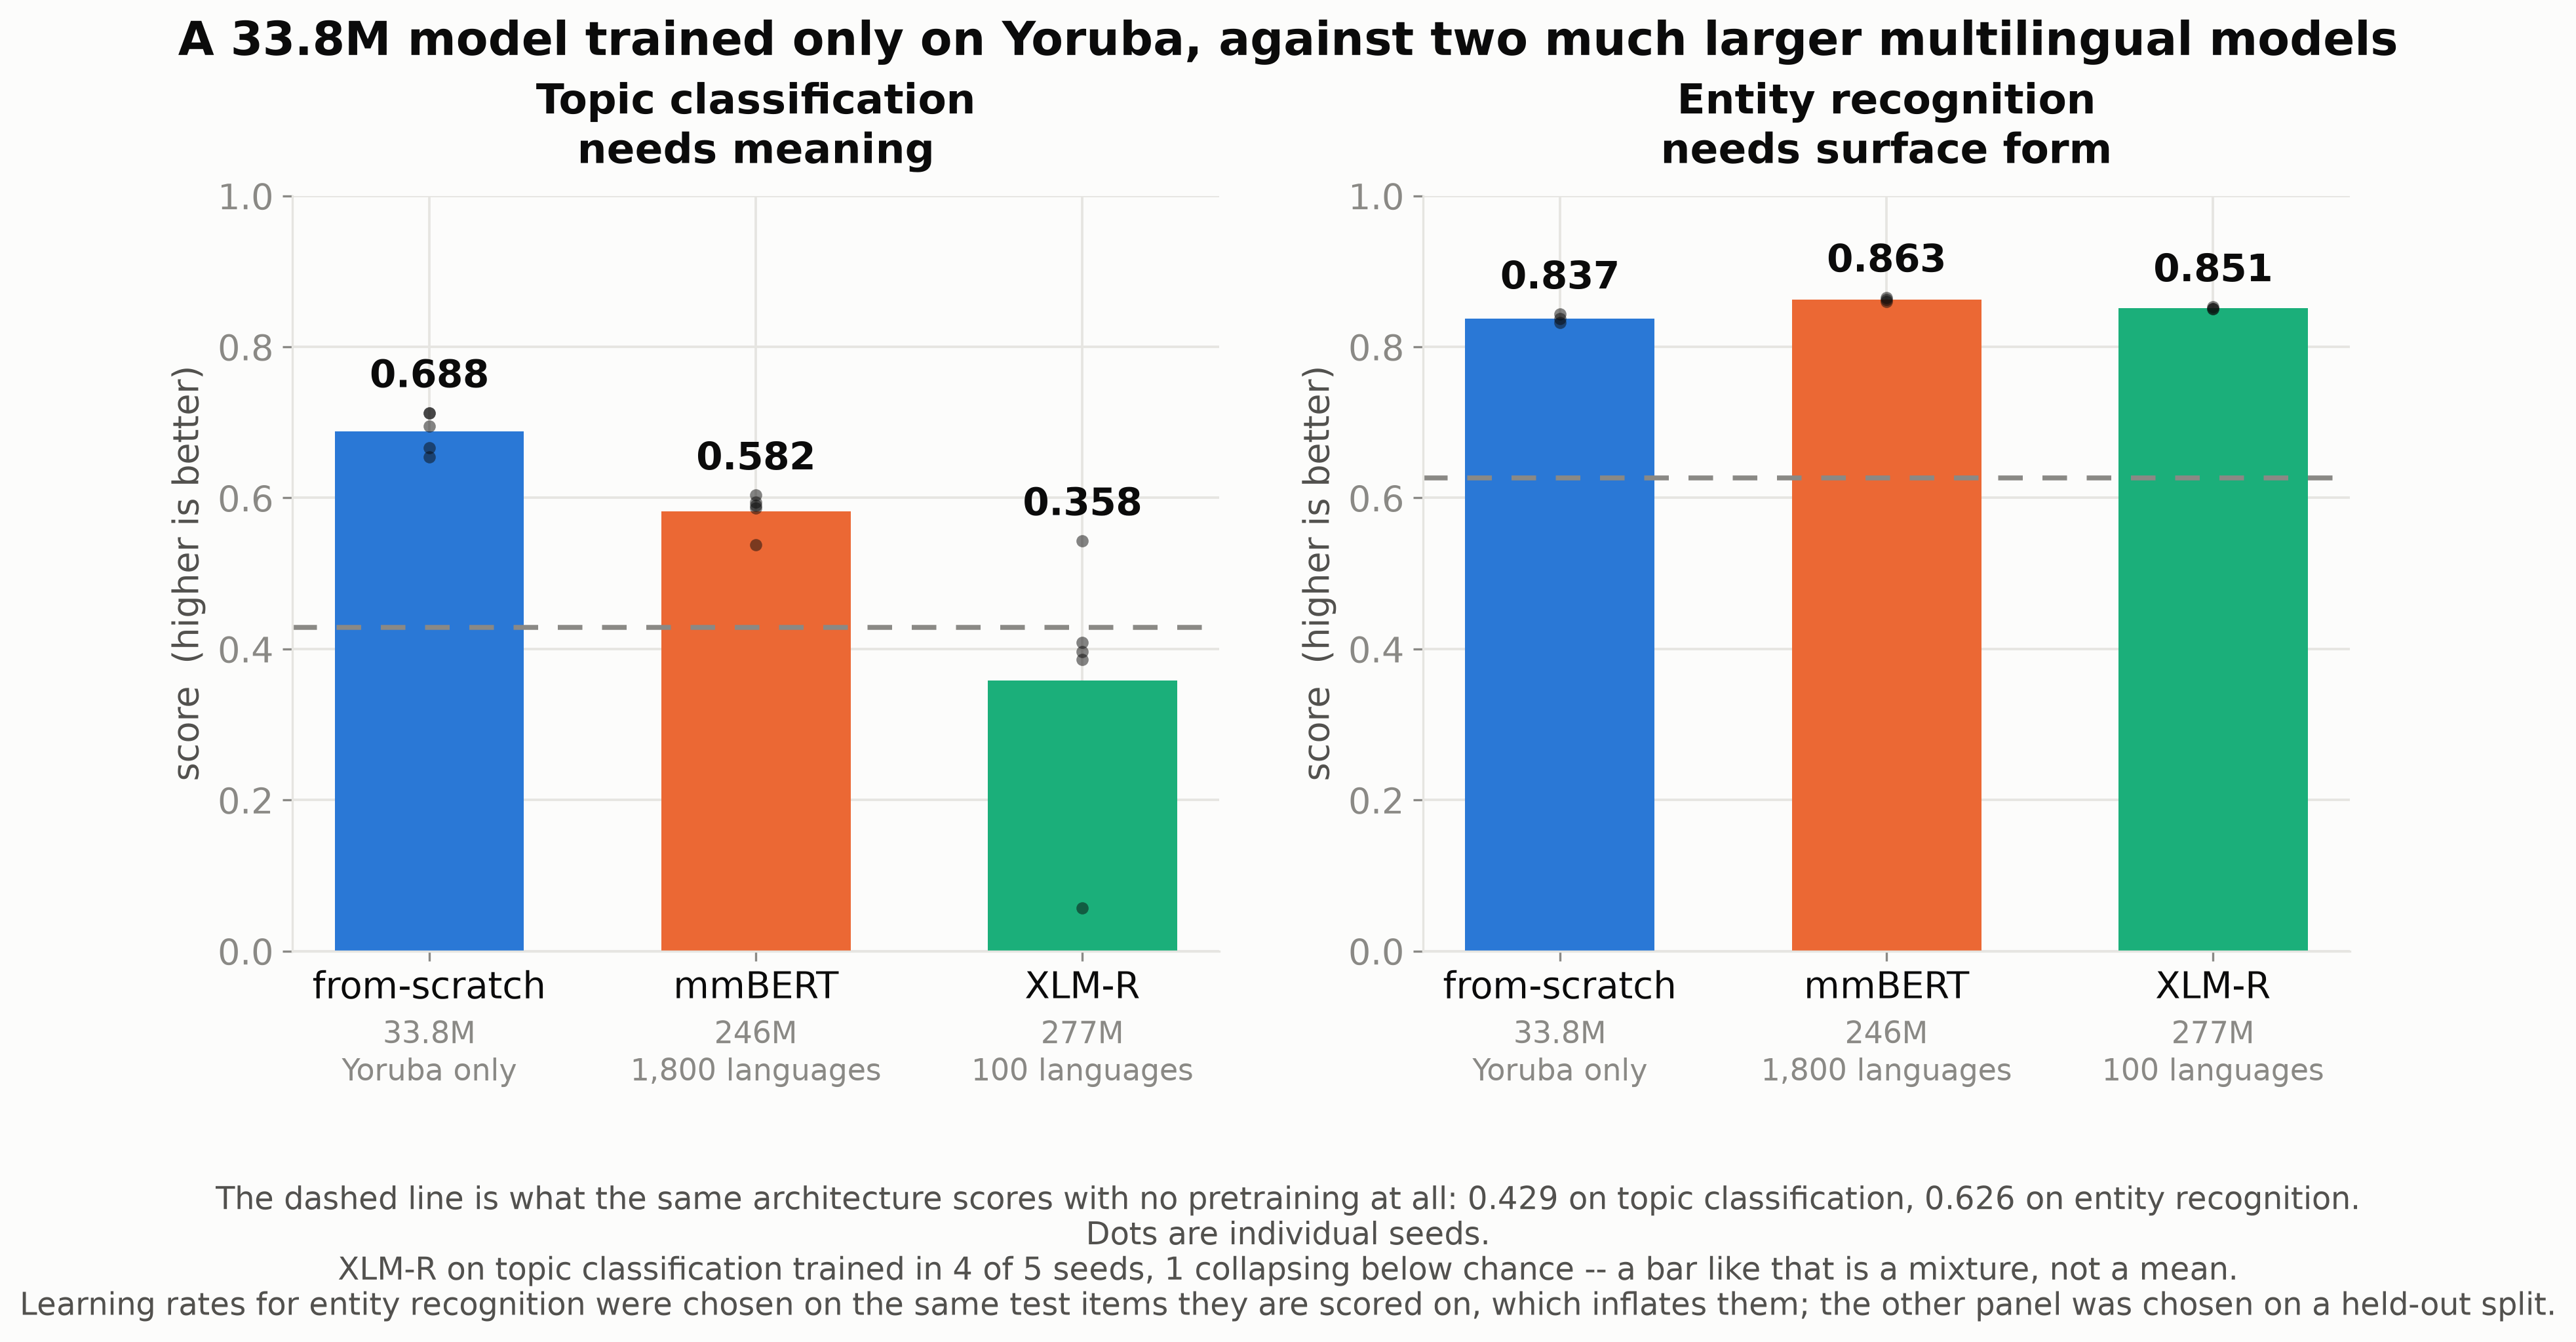

In [3]:
def best_arm(frag, task, steps):
    """Best of a model's learning-rate sweep on one task. Returns the whole record, not just
    the score, because the interval is the point."""
    c = [r for r in DOWN if frag in r['model'] and r.get('task') == task
         and r.get('steps') == steps]
    return max(c, key=lambda r: r['mean']) if c else None


ARMS = [('from-scratch, ours (33.8M)', 'yor_64M'), ('mmBERT (246M)', 'mmBERT'),
        ('XLM-R (277M)', 'xlm-roberta-base'), ('our arch, untrained', 'yor_random_init')]
TASKS = [('Topic classification (SIB-200)', 'sib200', 1056),
         ('Entity recognition (MasakhaNER)', 'masakhaner', 2150)]

rows = []
for tname, task, steps in TASKS:
    for label, frag in ARMS:
        r = best_arm(frag, task, steps)
        if not r:
            continue
        ci = r.get('ci') or [None, None]
        rows.append({'task': tname, 'model': label, 'score': round(r['mean'], 4),
                     'ci_low': round(ci[0], 3) if ci[0] else None,
                     'ci_high': round(ci[1], 3) if ci[1] else None,
                     'best_lr': r['lr'], 'n_lrs_swept': sum(
                         1 for x in DOWN if frag in x['model'] and x.get('task') == task
                         and x.get('steps') == steps),
                     'selected_on': 'test' if '_onval' not in r['tag'] else 'dev'})
display(pd.DataFrame(rows))

# The margin, and the tests that decide whether it is real -- computed, not asserted.
ours = best_arm('yor_64M', 'sib200', 1056)
mmb = best_arm('mmBERT', 'sib200', 1056)
margin = ours['mean'] - mmb['mean']
overlap = ours['ci'][0] < mmb['ci'][1]
claim('SIB-200, ours', ours['mean'], 'model trained on 64 million words of Yoruba scored')
claim('SIB-200, mmBERT', mmb['mean'], 'words across 1,800 languages — scored')
claim('SIB-200 margin', margin, 'the margin *grows* to')

# The verb is "beats", and the reason is NOT that the intervals separate -- they do not, by
# 0.004. Interval overlap is the wrong test: two 95% intervals miss each other only when the
# margin clears 1.96*(SE_a + SE_b), which assumes the two models' per-item errors are perfectly
# ANTI-correlated. Both arms are scored on the same 204 items, so that is the least plausible
# assumption available, and its effective alpha is 0.0056 rather than 0.05.
print(f'margin {margin:.4f}   intervals overlap: {overlap} (by 0.004)')
print('the overlap is not the test -- see claims_audit below: exact permutation p = 0.008,')
print('4.05x the pooled seed spread against the 1.46x a test needs at five seeds,')
print('and p = 0.014 once test-set uncertainty is added back. The verb is BEATS.')

show('01-headline')

---
## Panels 2–3 — Yoruba against English, and why sixteen other languages

"Low-resource" is a phrase; this is the number behind it. And the other languages are not drift —
English is the ruler, Mandarin and French are the control that kills "maybe it's just African
languages".

In [4]:
scale = []
for name, pretty in (('eng_1b', 'English'), ('yor', 'Yoruba')):
    s = json.load(open(f'data/{name}/stats.json', encoding='utf-8'))
    scale.append({'corpus': pretty, 'characters': s['chars'],
                  'train tokens': s['n_tokens']['train'],
                  'chars per token': round(s['chars_per_token'], 2)})
df_scale = pd.DataFrame(scale)
display(df_scale)

ratio = df_scale.loc[0, 'characters'] / df_scale.loc[1, 'characters']
print(f'English has {ratio:.0f}x more text than everything we could collect in Yoruba.')

# Every corpus the factory has prepared, and whether it was for the gradient or the ladder.
prepared = sorted(d for d in os.listdir('data')
                  if os.path.exists(f'data/{d}/stats.json'))
print(f'\n{len(prepared)} corpora prepared: {", ".join(prepared)}')
claim('corpora prepared', len(prepared), '22 corpora and 17 languages')

,corpus,characters,train tokens,chars per token
0,English,4675005839,1096781996,4.25
1,Yoruba,259864169,69096452,3.73


English has 18x more text than everything we could collect in Yoruba.

22 corpora prepared: afr, amh, cmn, eng, eng_1b, fra, hau, ibo, ind, kin, lug, nya, shakespeare, sna, som, swh, wikitext103, wikitext2, wol, xho, yor, yor_xlmr


22

### What a multilingual vocabulary costs, per language

The ratio is how many XLM-R tokens it takes to cover one token of a purpose-built vocabulary.
Above 1.0 is a penalty. **The split falls exactly along whether XLM-R was trained on the
language** — which is what the covered languages are in the study to establish.

17 corpora
  XLM-R was trained on it     n=10  mean penalty 1.150
  XLM-R was not               n= 7  mean penalty 1.593

uncovered but cheap (the exception): wol 1.31


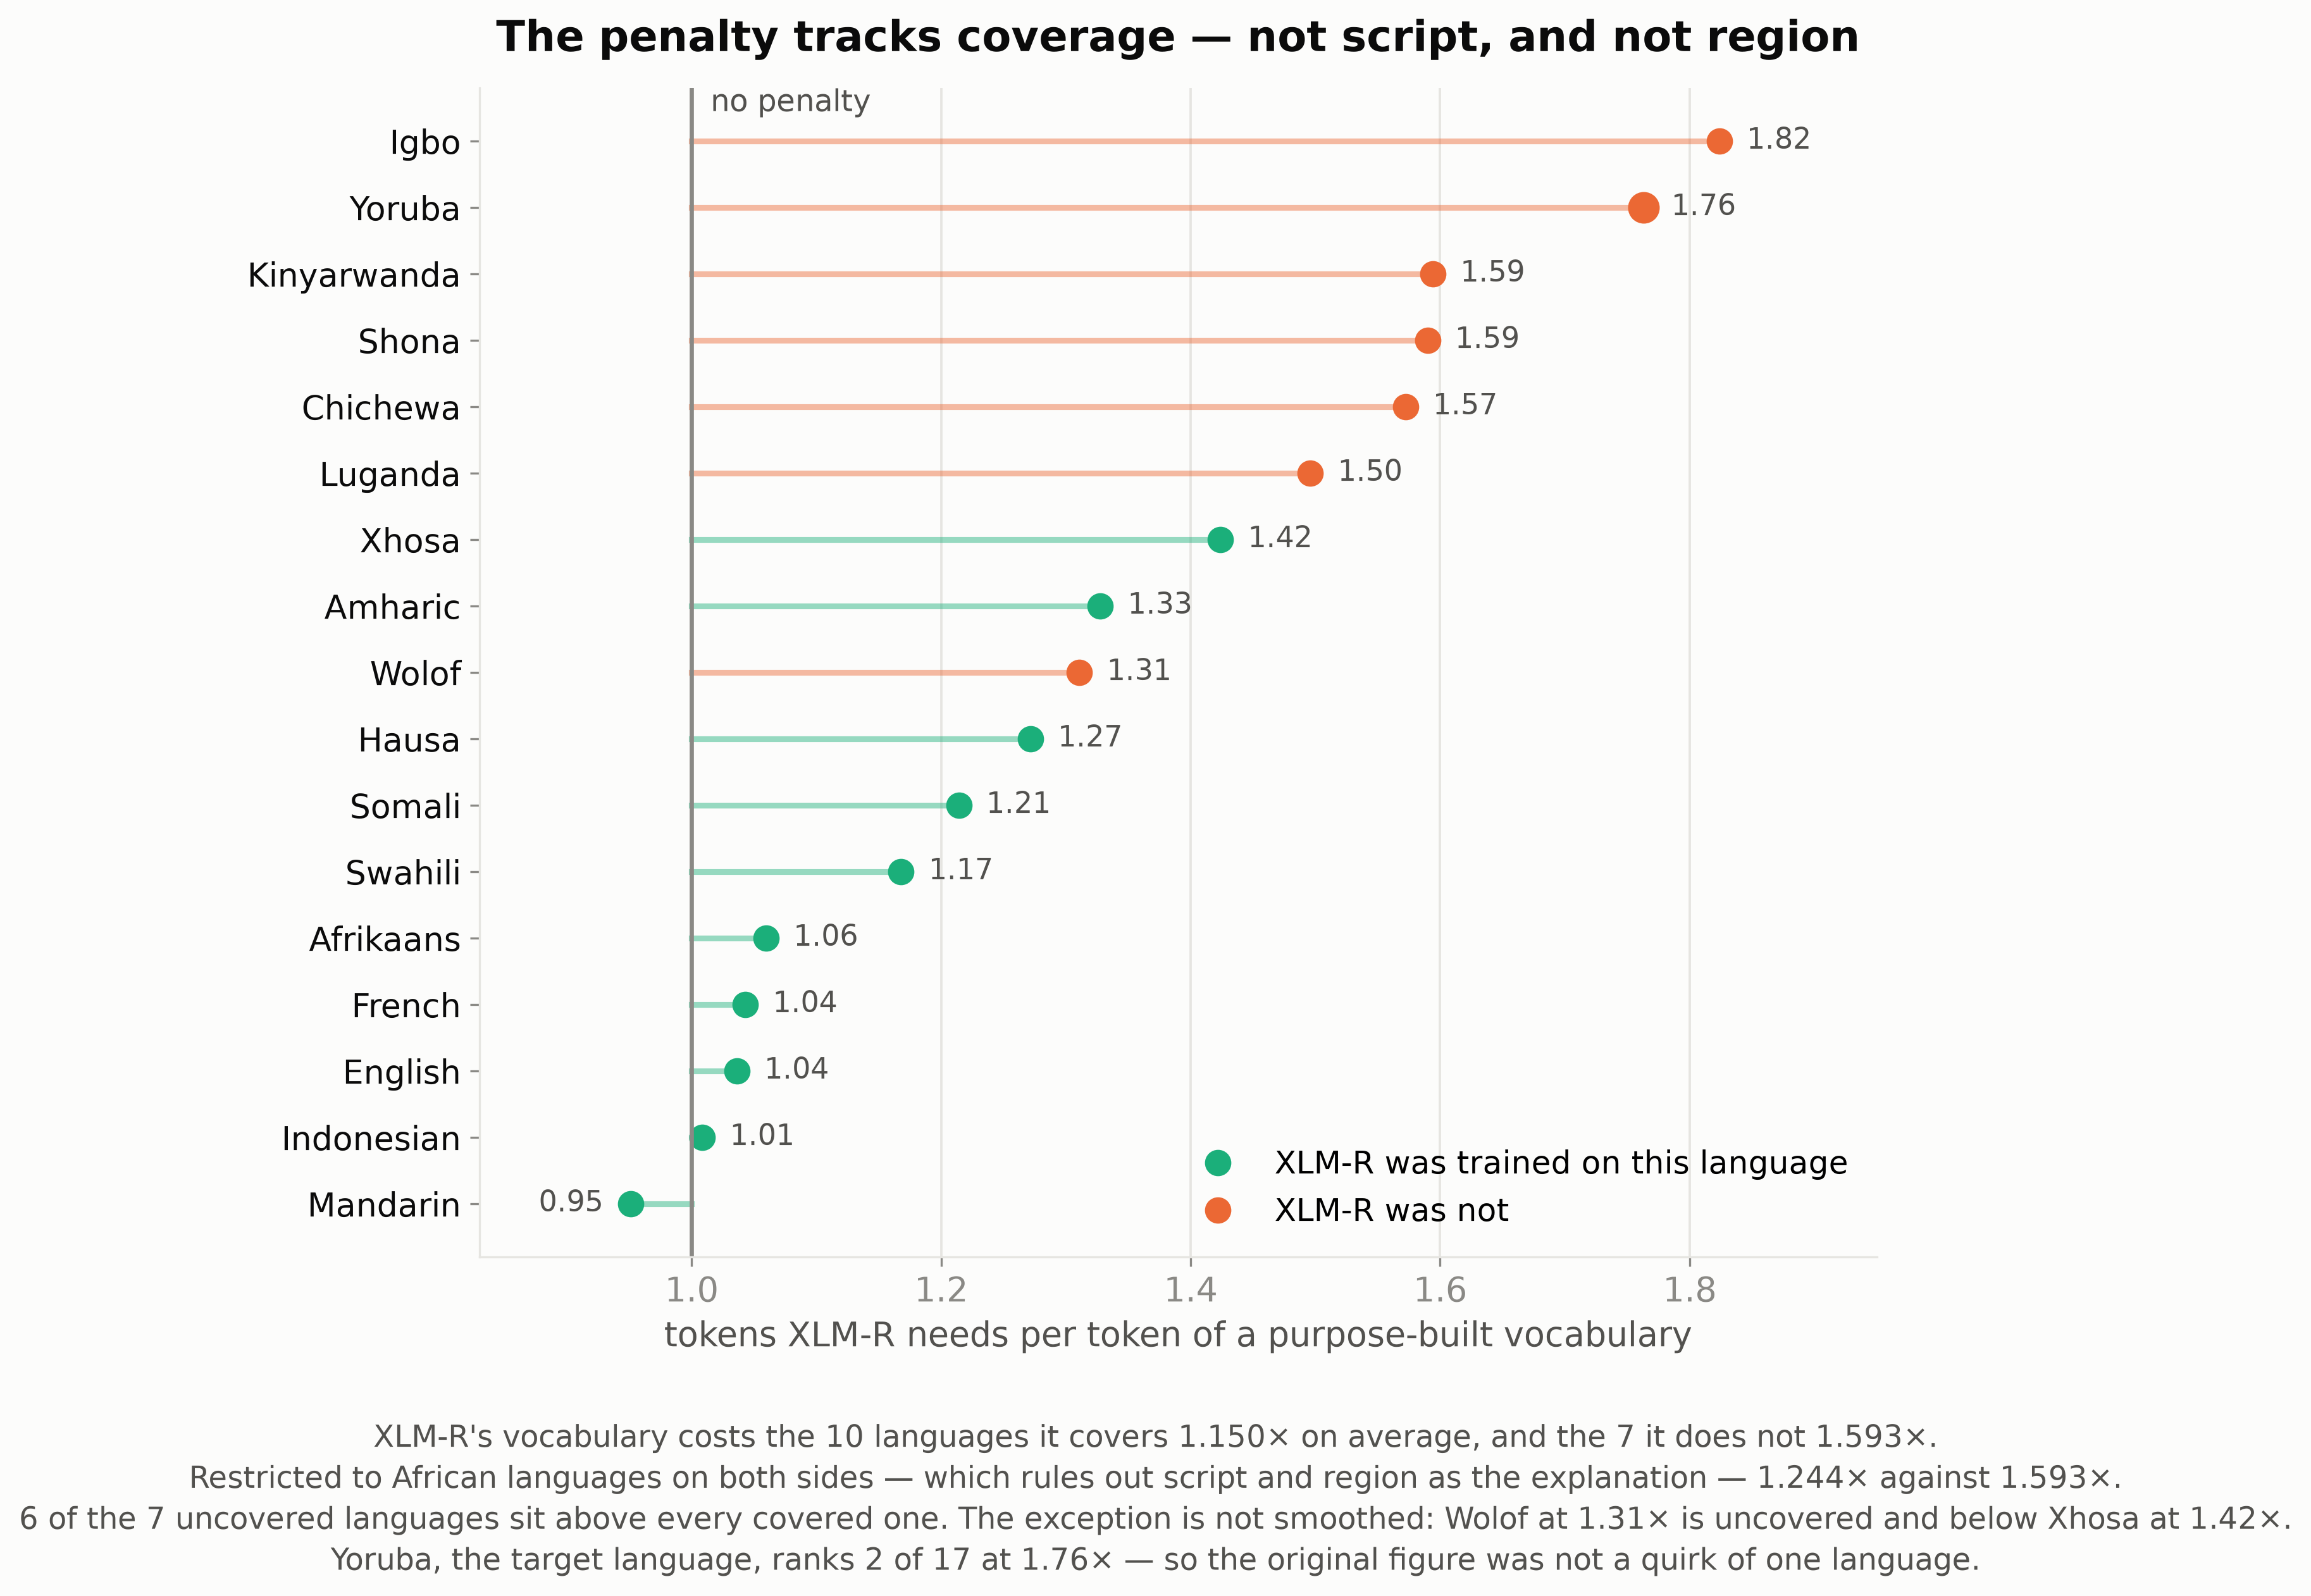

In [5]:
grad = [r for r in json.load(open('runs/gradient_table.json', encoding='utf-8'))
        if r['corpus'] != 'eng_1b']
cov = [r['penalty'] for r in grad if r['in_xlmr'] is True]
unc = [r['penalty'] for r in grad if r['in_xlmr'] is not True]
print(f'{len(grad)} corpora')
print(f'  XLM-R was trained on it     n={len(cov):>2}  mean penalty {st.mean(cov):.3f}')
print(f'  XLM-R was not               n={len(unc):>2}  mean penalty {st.mean(unc):.3f}')

# The exception matters more than the trend -- one language breaks it, and an anecdote would
# have hidden that.
odd = [r for r in grad if r['in_xlmr'] is not True and r['penalty'] < max(cov)]
print('\nuncovered but cheap (the exception): '
      + ', '.join(f"{r['corpus']} {r['penalty']:.2f}" for r in odd))

show('02-tokenizer-gradient')

---
## Panels 5–7 — The factory: the interface, and what it costs to call

The whole surface Patrick and Leon call. Nine functions to pretrain, six to fine-tune and score.
This cell prints the live signatures rather than a copy of them, so the poster cannot show an
interface that no longer exists.

In [6]:
import inspect

SURFACE = ['prepare_corpus', 'corpus_info', 'estimate', 'pretrain', 'random_init',
           'random_init_like', 'results', 'curve', 'bits_per_char']
print('mlm_api  (pretraining)')
for n in SURFACE:
    fn = getattr(factory, n)
    sig = str(inspect.signature(fn))
    print(f'  factory.{n}{sig[:96]}')

print('\nft_api  (downstream)')
for n in ('finetune_once', 'evaluate', 'table', 'results'):
    print(f'  ft.{n}{str(inspect.signature(getattr(ft_api, n)))[:96]}')

print(f'\nft_api.API_VERSION = {ft_api.API_VERSION}   '
      '(pin against it if a script must not silently change behavior)')

mlm_api  (pretraining)
  factory.prepare_corpus(name: 'str', lang: 'str', wiki: 'str | None' = None, vocab_size: 'int' = 16000, max_len: 'int' 
  factory.corpus_info(name: 'str') -> 'dict'
  factory.estimate(name: 'str', cells: 'list[tuple[int, int]]', preset: 'str' = 'poc', batch: 'int' = 128, seq_len
  factory.pretrain(name: 'str', tokens: 'int', steps: 'int', seed: 'int' = 0, preset: 'str' = 'poc', batch: 'int' 
  factory.random_init(name: 'str', preset: 'str' = 'poc', seq_len: 'int' = 128) -> 'str'
  factory.random_init_like(model_id: 'str', tag: 'str | None' = None) -> 'str'
  factory.results(pattern: 'str' = '*', include_smoke: 'bool' = False) -> 'list[dict]'
  factory.curve(tag: 'str') -> 'list[dict]'
  factory.bits_per_char(tag: 'str' = None, *, val_loss: 'float' = None, corpus: 'str' = None) -> 'float'

ft_api  (downstream)
  ft.finetune_once(model_path: 'str', task: 'str' = 'sib200', lang: 'str | None' = None, lr: 'float | None' = None
  ft.evaluate(model_path: 'str', task: '

### The pipeline, stage by stage

Training is the part people picture. It is not the whole job — but it is almost all of the time.
Measured on the real Yoruba corpus by `pipeline_bench.py`; re-run that script to refresh.

In [7]:
bench = json.load(open('runs/pipeline_bench.json', encoding='utf-8'))
print(f"{bench['corpus']}: {bench['docs']:,} documents, {bench['chars']:,} characters, "
      f"{bench['train_tokens']:,} tokens\n")
for s in bench['stages']:
    bits = '  '.join(f'{k}={v}' for k, v in s.items()
                     if k != 'name' and k != 'note' and v is not None)
    print(f"{s['name']:<32} {bits}")

prep = sum(s.get('seconds', 0) for s in bench['stages'] if s['name'][0] in '123')
train_h = next(s['hours_for_62500_steps'] for s in bench['stages'] if '98M' in s['name'])
print(f'\npreparation: {prep:.0f} s      training: {train_h*60:.0f} min')
print(f'ratio: training is {train_h*3600/prep:.0f}x the preparation')
print('\nWhich is the whole reason the factory is shaped the way it is: everything cheap happens\n'
      'interactively, everything expensive goes in a queue that runs while nobody is watching.')

yor: 79,999 documents, 259,864,169 characters, 69,096,452 tokens

1. read documents                seconds=0.06  docs=4000  chars_per_s=196082839  extrapolated_full_s=1
2. train 16k BPE tokenizer       seconds=20.7  trained_on_chars=12745110  device=CPU
3. encode to token ids           seconds=1.1  tokens=3437890  tokens_per_s=3253320  extrapolated_full_s=21  dtype=uint16  device=CPU
4. token store                   disk_gb=0.129  bytes_per_token=2
5. corpus onto the GPU           seconds=11.4  resident_gb=0.129
6. train step, 33.8M model       tokens_per_s=469602  peak_gb=5.79  hours_for_62500_steps=0.61
6. train step, 98M model         tokens_per_s=201212  peak_gb=10.0  hours_for_62500_steps=1.41

preparation: 22 s      training: 85 min
ratio: training is 232x the preparation

Which is the whole reason the factory is shaped the way it is: everything cheap happens
interactively, everything expensive goes in a queue that runs while nobody is watching.


---
## Panel 9 — What the 105 runs were for, and why three seeds

Not a grid search. A grid search asks *which settings win*; we were asking *is this difference
real*, and those need different amounts of compute — one run per setting versus several runs of
each.

In [8]:
def dist(key, rows=None):
    c = collections.Counter(r.get(key) for r in (rows or PRE))
    return dict(sorted(((str(k), v) for k, v in c.items()), key=lambda kv: kv[0]))


print('The hyperparameters we genuinely did search:')
for k in ('lr', 'batch', 'seq_len', 'steps', 'seed', 'clip', 'warmup', 'preset'):
    print(f'  {k:<9} {dist(k)}')

print('\nDownstream learning rates swept:',
      sorted({r['lr'] for r in DOWN}))

# Model sizes, as TOTAL parameters. We called the middle one "the 86M model" all term; 86M is its
# count excluding the embedding table, which is not comparable to mmBERT's 246M or XLM-R's 277M.
sizes = sorted({(round(r['params'] / 1e6), round(r['nonemb_params'] / 1e6)) for r in PRE})
print('\nmodel sizes (total M, non-embedding M):', sizes)

The hyperparameters we genuinely did search:
  lr        {'0.0001': 1, '0.00015': 13, '0.0003': 71, '0.0005': 81, '0.0007': 10, '0.00085': 10, '0.001': 11}
  batch     {'128': 191, '256': 1, '512': 1, '64': 4}
  seq_len   {'128': 197}
  steps     {'11719': 5, '12000': 92, '24000': 2, '2930': 3, '3000': 2, '35156': 1, '4000': 6, '46875': 3, '6000': 2, '62500': 81}
  seed      {'0': 95, '1': 53, '10': 2, '11': 2, '2': 23, '3': 6, '4': 4, '5': 4, '6': 2, '7': 2, '8': 2, '9': 2}
  clip      {'0.5': 22, '1.0': 93, 'None': 82}
  warmup    {'0.06': 135, 'None': 62}
  preset    {'afriberta': 70, 'poc': 127}

Downstream learning rates swept: [5e-06, 1e-05, 2e-05, 3e-05, 5e-05, 7e-05, 0.0001, 0.0002, 0.0003, 0.0005, 0.0007, 0.001]

model sizes (total M, non-embedding M): [(34, 26), (98, 86), (154, 26)]


52 of 94 cells were run at more than one seed

  smallest spread  0.000
  median spread    0.071
  largest spread   2.168

  ratio largest:smallest = 5136x

A single constant cannot describe that. The rule we ended up with: run the cell at three
seeds BEFORE comparing it to anything, and treat a difference smaller than that cell's own
spread as no difference at all.


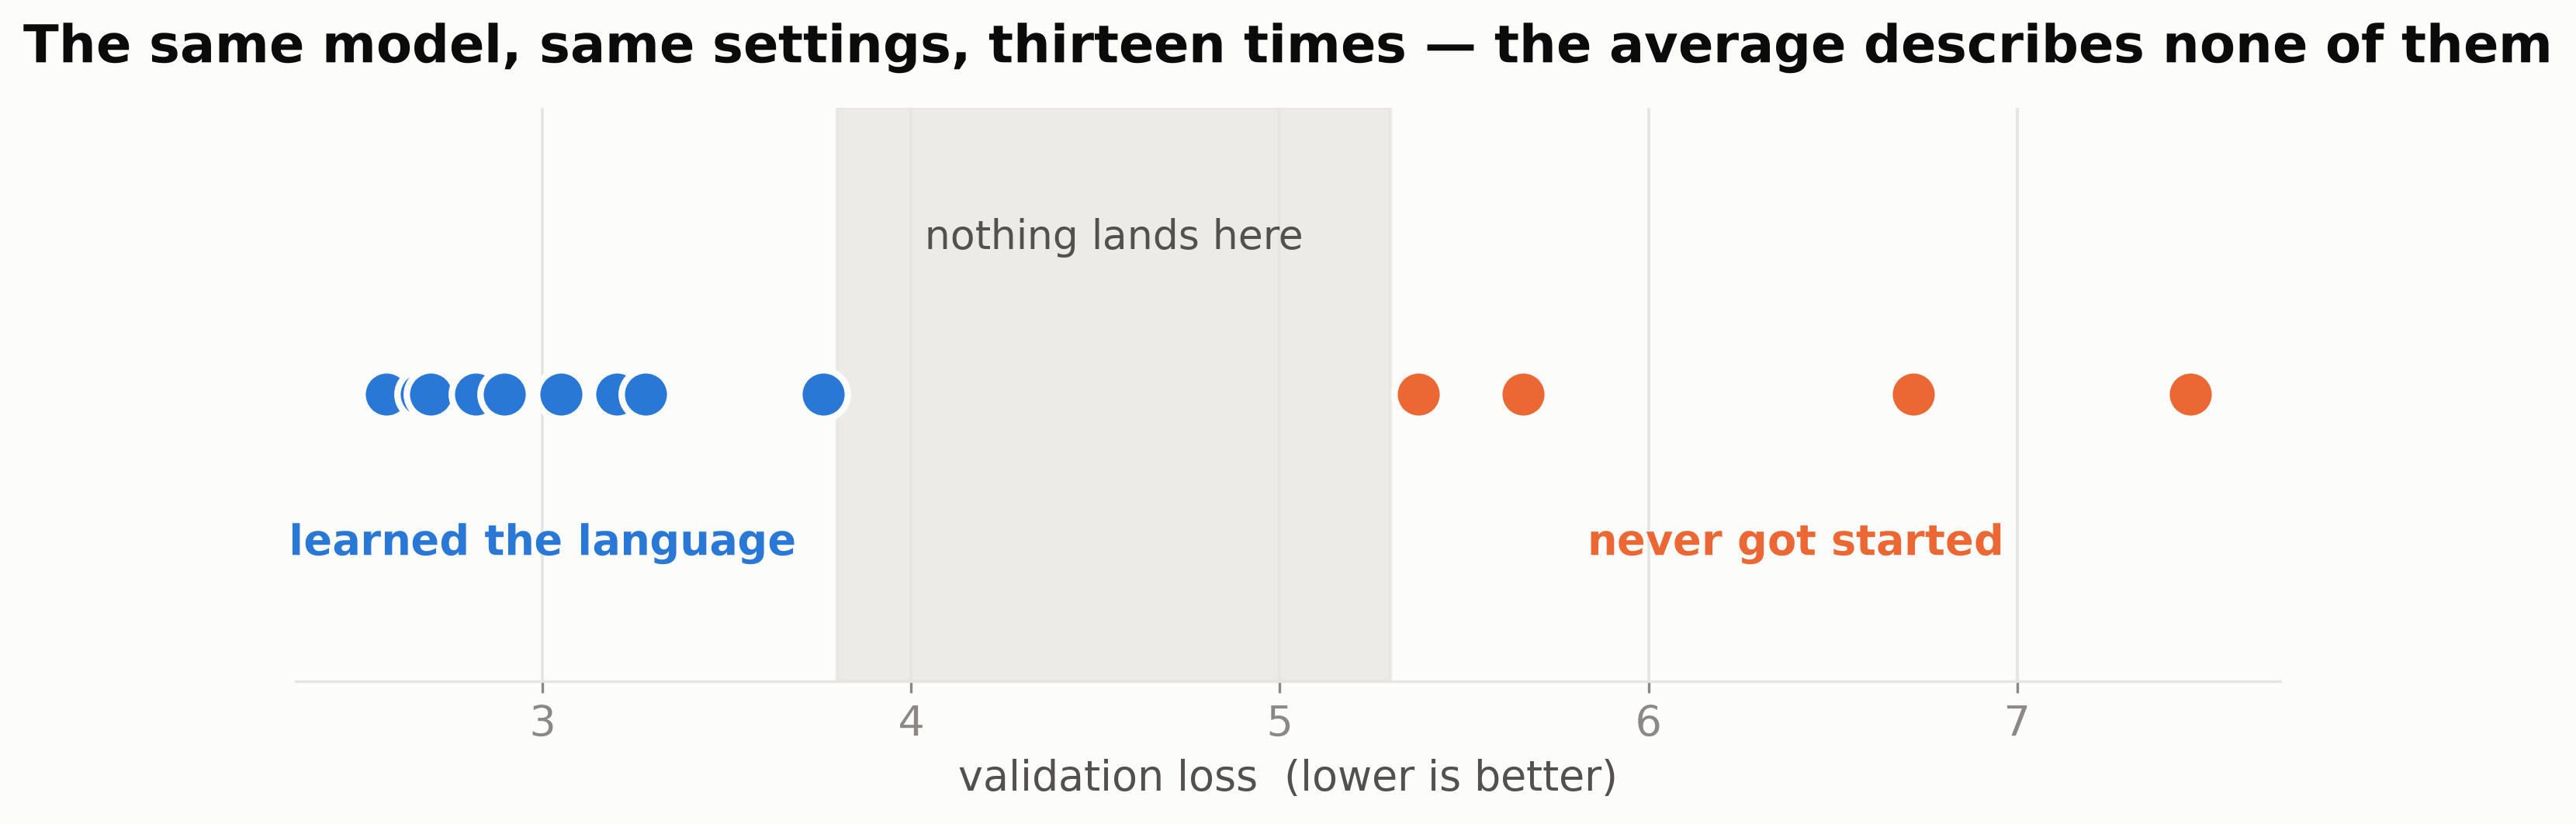

In [9]:
# Why three seeds: the run-to-run spread is a PER-CELL property, not a constant. For most of the
# term we used one number -- 0.049, measured once on one model on one language -- everywhere.
cells = collections.defaultdict(list)
for r in PRE:
    key = (r.get('corpus'), r['n_tokens'], r['steps'], r.get('preset'), r['lr'], r.get('clip'))
    cells[key].append(r['val_loss'])
multi = {k: v for k, v in cells.items() if len(v) > 1}
sds = sorted(st.stdev(v) for v in multi.values())

print(f'{len(multi)} of {len(cells)} cells were run at more than one seed\n')
print(f'  smallest spread  {sds[0]:.3f}')
print(f'  median spread    {st.median(sds):.3f}')
print(f'  largest spread   {sds[-1]:.3f}')
print(f'\n  ratio largest:smallest = {sds[-1]/sds[0]:.0f}x')
print('\nA single constant cannot describe that. The rule we ended up with: run the cell at three\n'
      "seeds BEFORE comparing it to anything, and treat a difference smaller than that cell's own\n"
      'spread as no difference at all.')
claim('median seed spread', st.median(sds), 'It is not a constant.** The')
claim('largest seed spread', sds[-1], 'the largest **2.156**')

show('04-two-outcomes')

### The one that decided a conclusion: matched steps versus matched compute

Giving two models the same number of training steps sounds like the definition of a fair
comparison. One of them was five times more expensive per step.

  note: seed 3 has 2 records; using swap_yor_xlmr_yor_xlmr_121.3M_12k_s3


,arm,n,bits_per_char,sd,minutes
0,"16k vocab, 12,000 steps",4,1.131,0.029,8.052
1,"XLM-R's 250k vocab, 12,000 steps",6,0.989,0.145,42.232
2,"16k vocab, 62,500 steps",6,0.930,0.037,43.574



read at matched STEPS:   -0.142 bits/char -- and the 250k arm used 5.2x the GPU time to get there
read at matched COMPUTE: +0.059 bits/char at 6 seeds a side


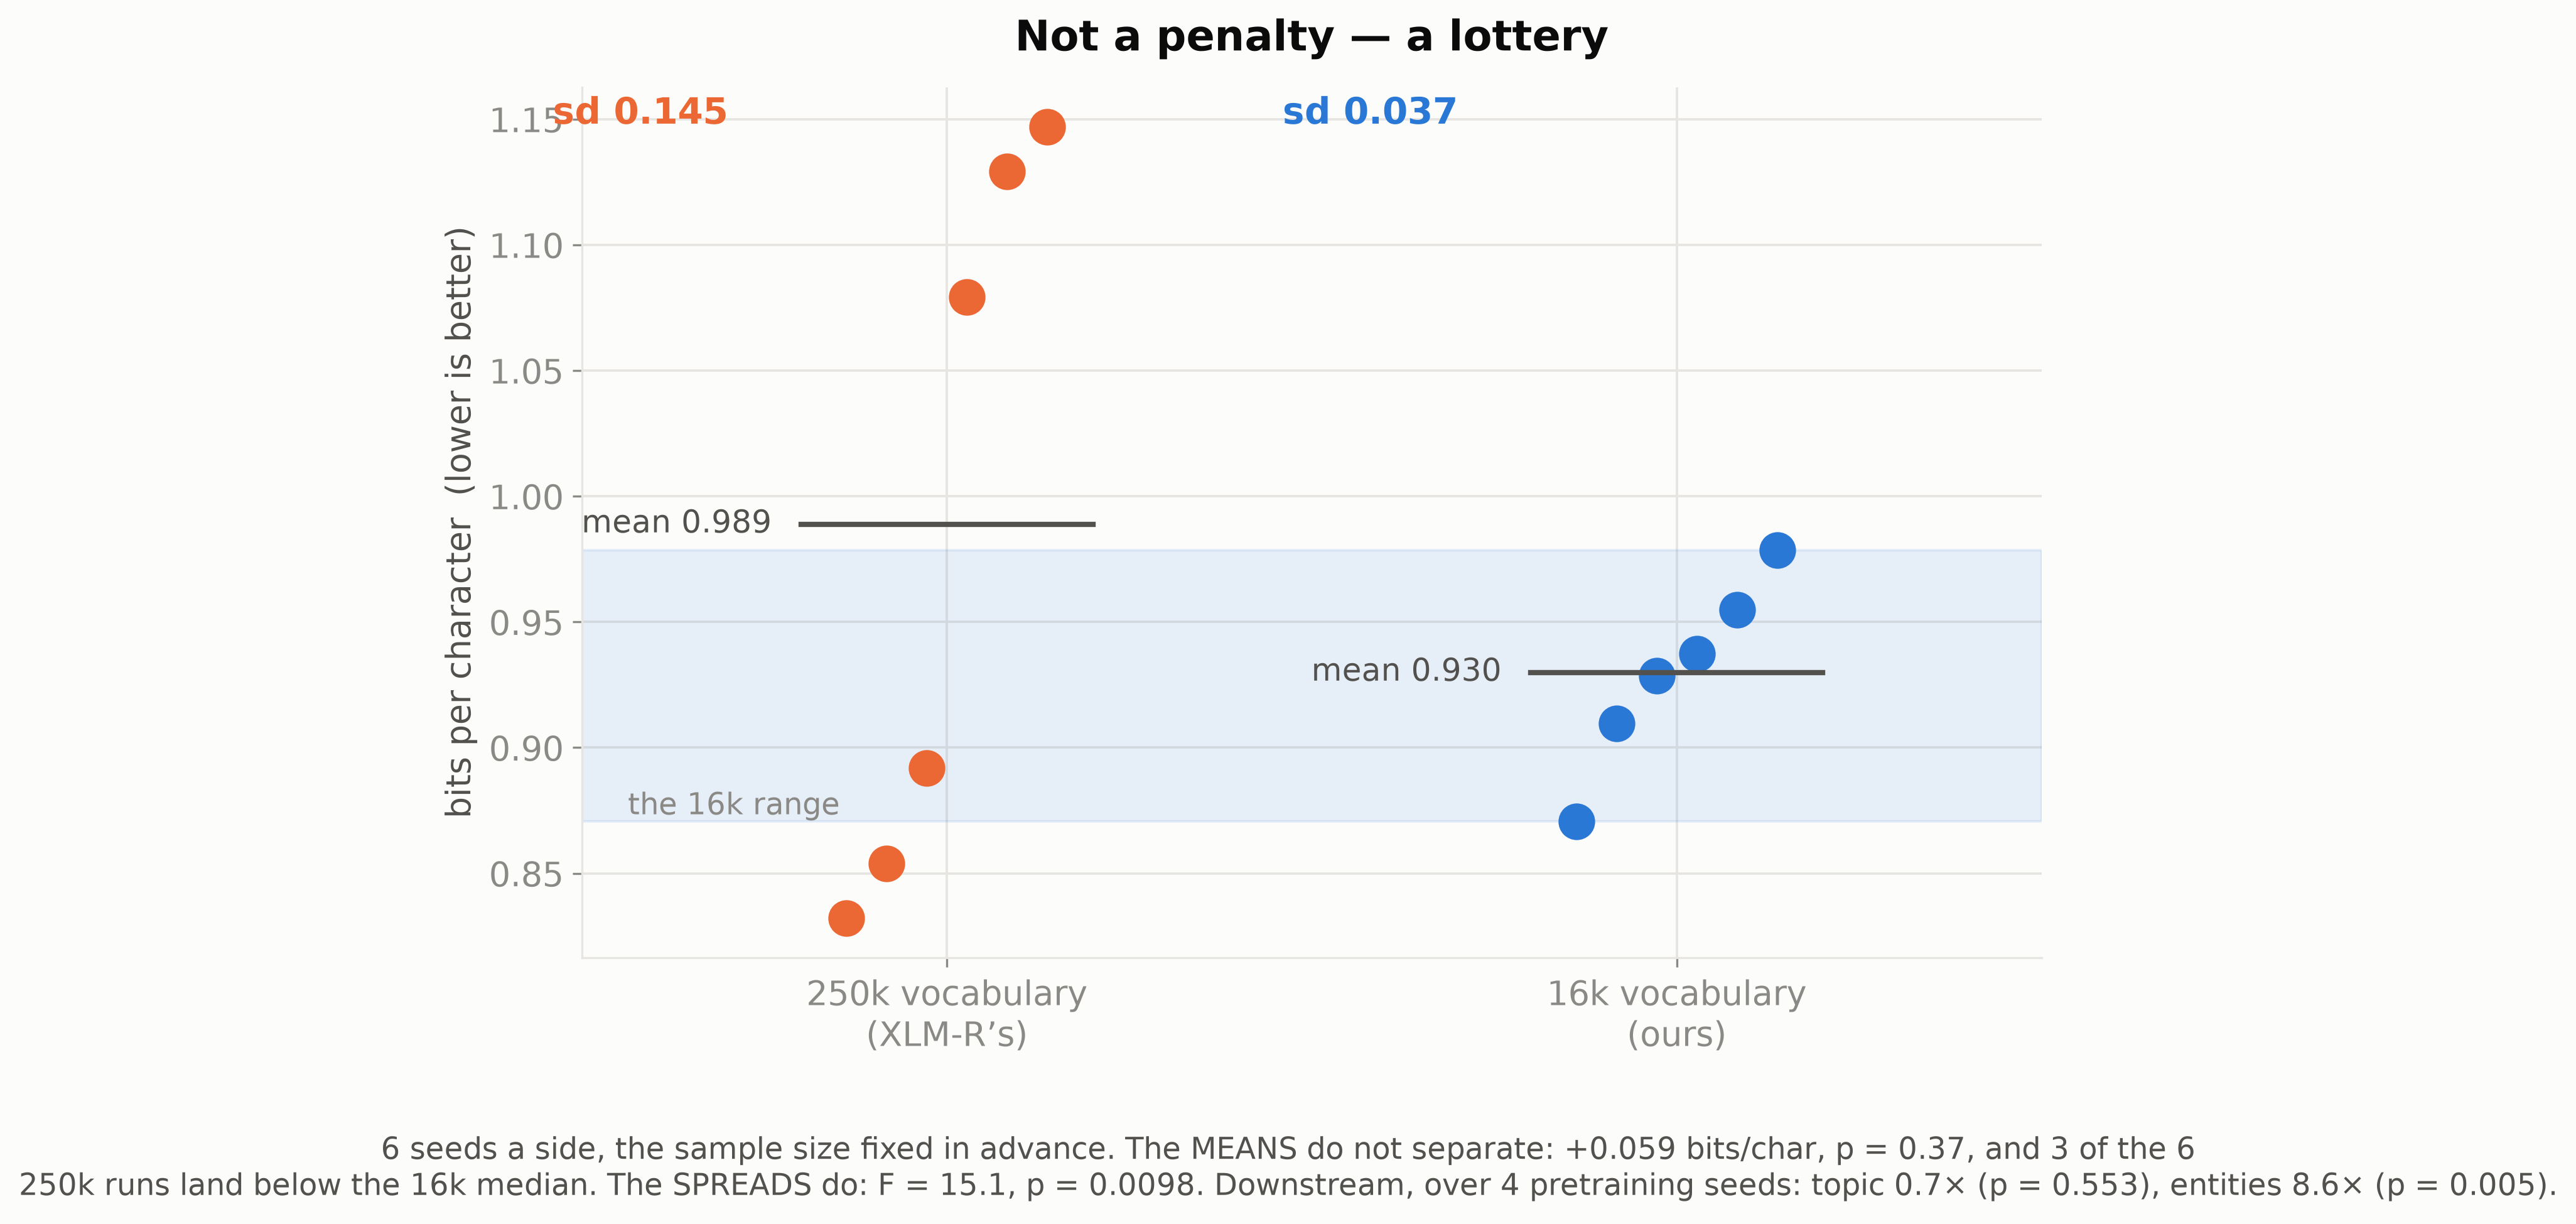

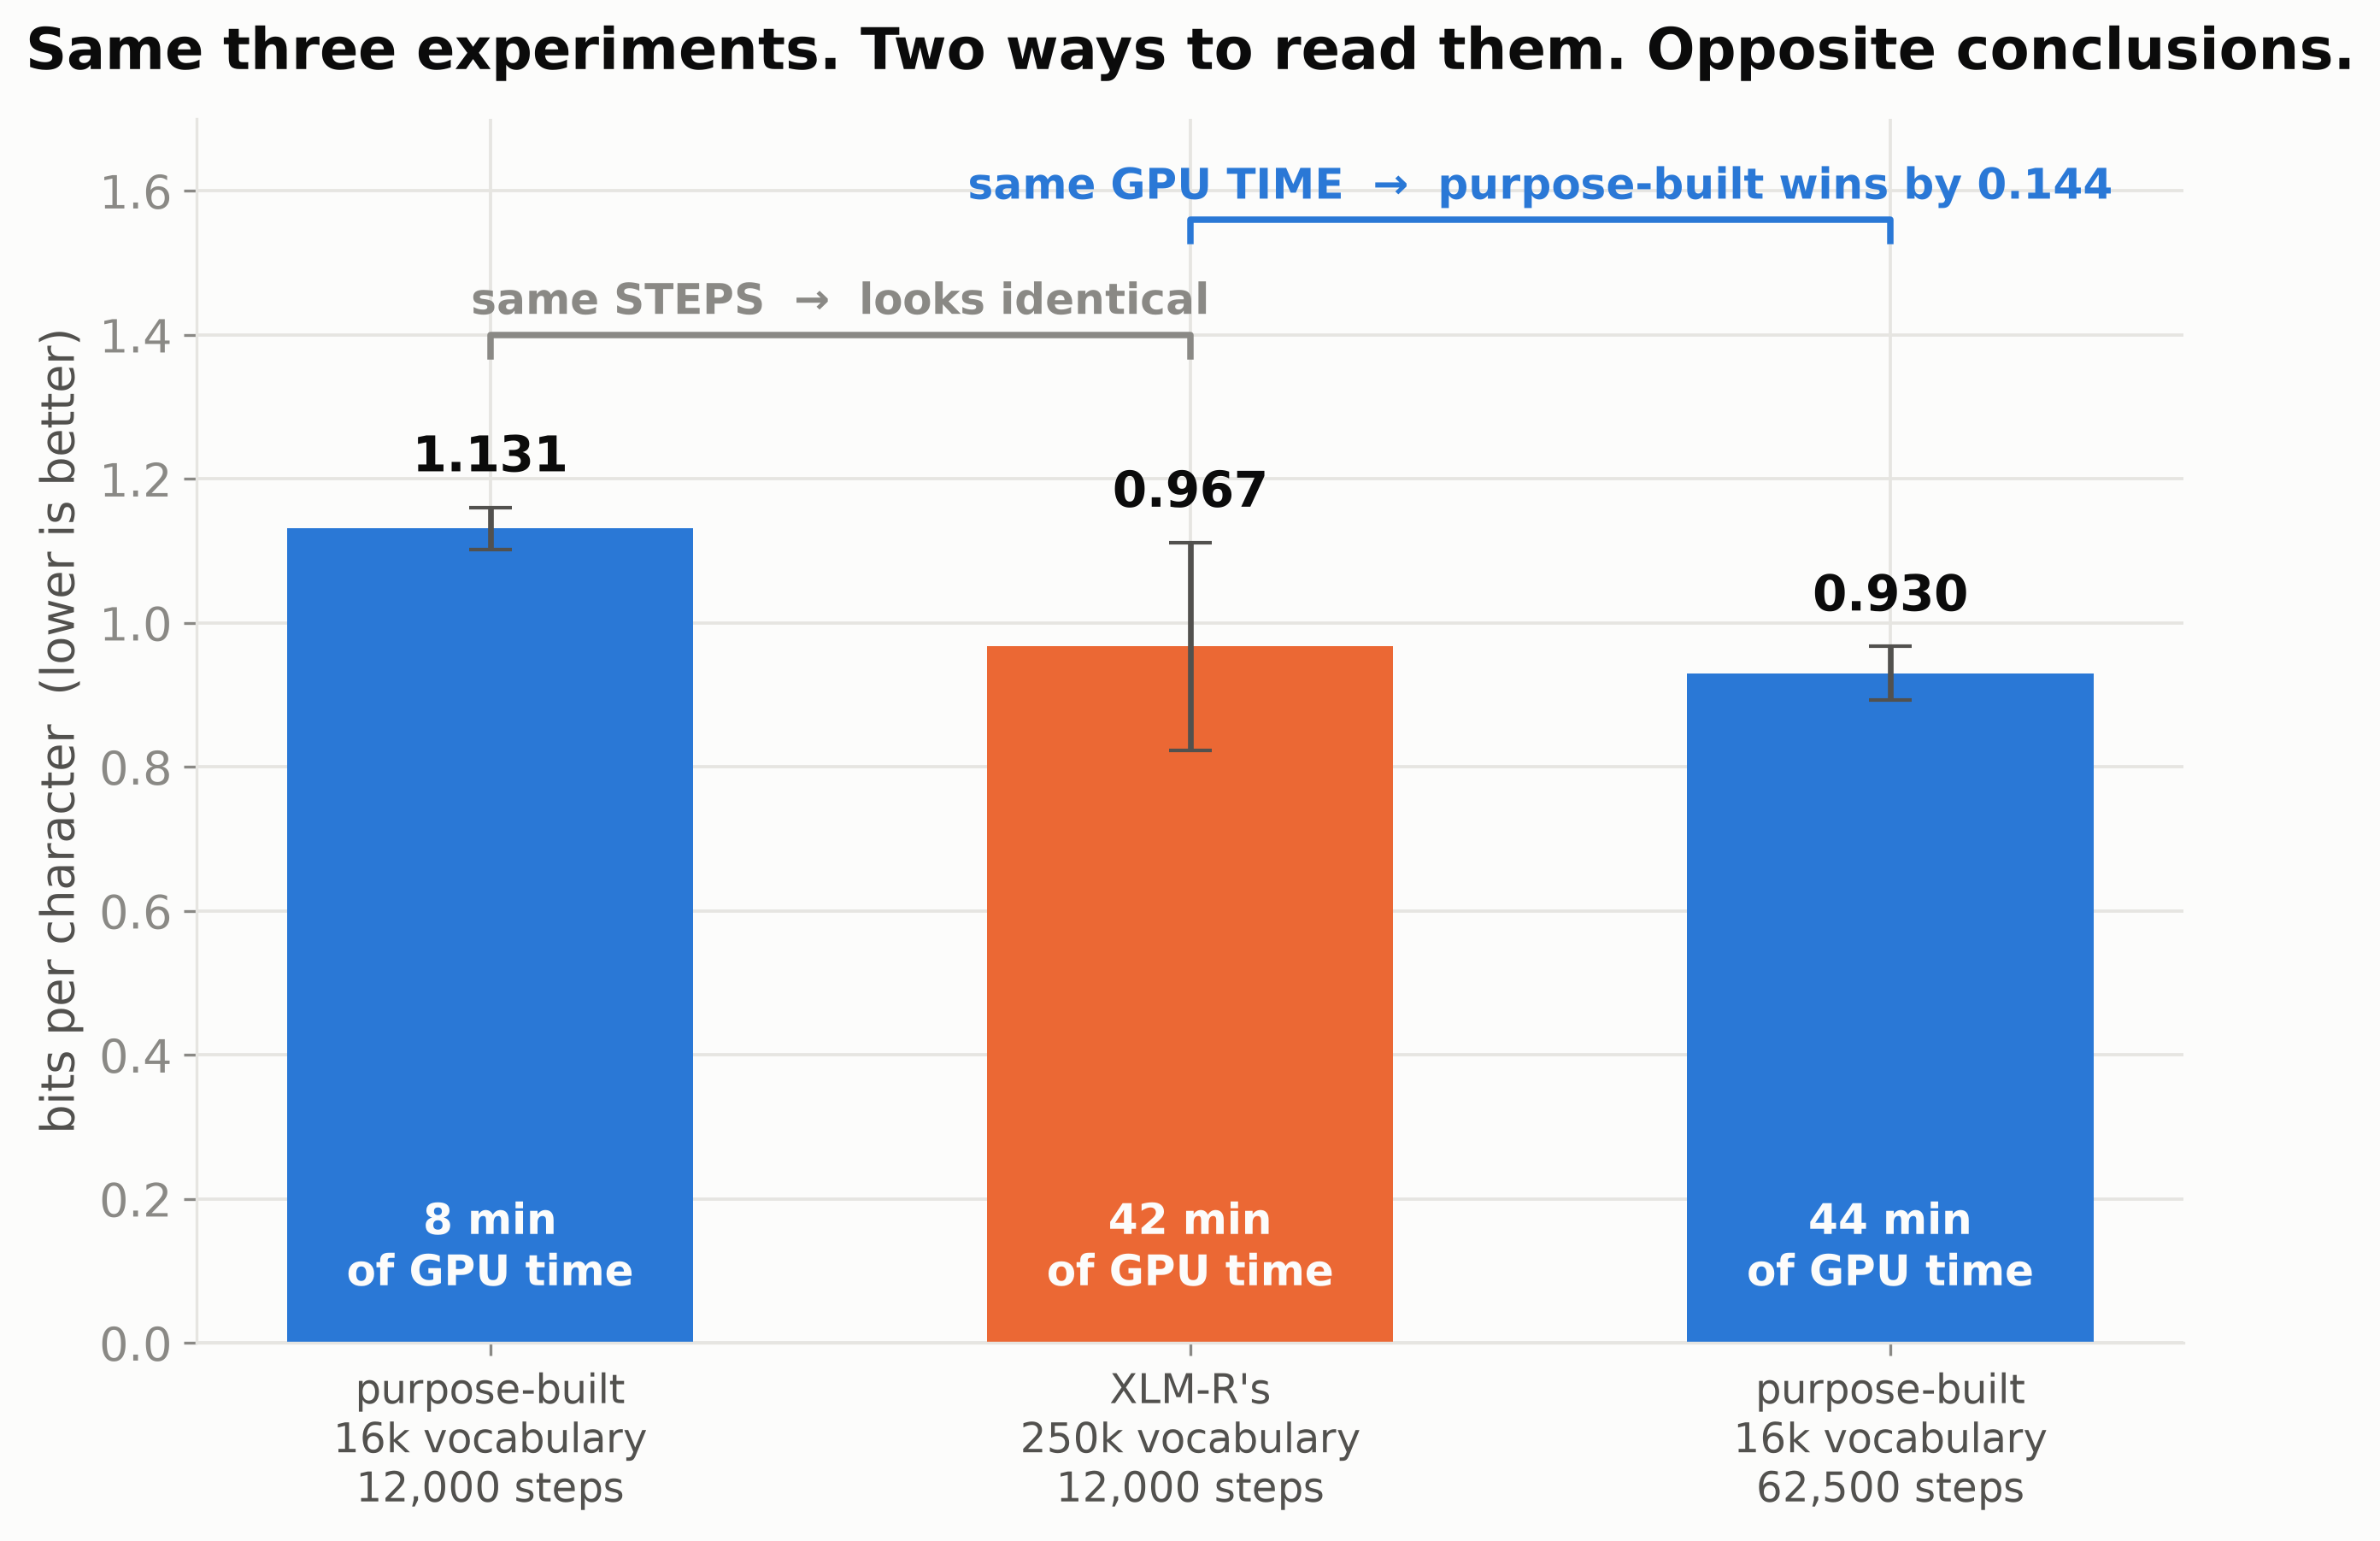

In [10]:
import study_tokenizer_seeds as tk


def arm(pattern, corpus):
    rr = [r for r in factory.results(pattern) if r.get('corpus') == corpus]
    cpt = factory.corpus_info(corpus)['chars_per_token']
    bpc = [r['val_loss'] / math.log(2) / cpt for r in rr]
    return {'n': len(rr), 'bits_per_char': st.mean(bpc), 'sd': st.stdev(bpc),
            'minutes': st.mean(r['seconds'] for r in rr) / 60}


def registered_arm(spec):
    """The seeds this experiment PRE-REGISTERED, not everything a glob happens to catch.

    `swap_yor_xlmr_*` was the obvious selector and it broke. Seeds 0-2 predate the
    `{prefix}_{cell_tag}` naming, this study's later seeds use it, and study_swap_downstream
    then built a fourth pretraining seed of its own under the older shape -- so the glob
    returns SEVEN runs for a six-seed arm. A pre-registered n = 6 quietly became n = 7 and the
    penalty moved from 0.059 to 0.037 without anybody asking for another seed.

    tk.arm_records() groups by seed, takes exactly the seeds the design named, and prints any
    seed holding more than one record rather than averaging them. Same selection the figure
    uses, so the notebook and the poster cannot disagree about what the arm is.
    """
    recs, dupes = tk.arm_records(spec)
    vals = sorted(tk.bpc(r, spec['corpus']) for r in recs.values())
    for seed, rows_, chosen in dupes:
        print(f'  note: seed {seed} has {len(rows_)} records; using {chosen}')
    return {'n': len(vals), 'bits_per_char': st.mean(vals), 'sd': st.stdev(vals),
            'minutes': st.mean(r['seconds'] for r in recs.values()) / 60}


BIG = next(x for x in tk.ARMS if x['corpus'] == 'yor_xlmr')
SMALL = next(x for x in tk.ARMS if x['corpus'] == 'yor')

a = arm('swap_yor_*', 'yor')     # 16k vocabulary, 12k steps -- the matched-STEPS comparison
b = registered_arm(BIG)          # 250k vocabulary, 12k steps -- six registered seeds
c = registered_arm(SMALL)        # 16k vocabulary, 62.5k steps -- matched WALL CLOCK

display(pd.DataFrame([dict(arm='16k vocab, 12,000 steps', **a),
                      dict(arm="XLM-R's 250k vocab, 12,000 steps", **b),
                      dict(arm='16k vocab, 62,500 steps', **c)]).round(3))

print(f'\nread at matched STEPS:   {b["bits_per_char"] - a["bits_per_char"]:+.3f} bits/char '
      f'-- and the 250k arm used {b["minutes"]/a["minutes"]:.1f}x the GPU time to get there')
print(f'read at matched COMPUTE: {b["bits_per_char"] - c["bits_per_char"]:+.3f} bits/char '
      f'at {b["n"]} seeds a side')

# At six seeds this is NOT a penalty and the panel must not call it one. The gap shrank from
# 0.144 to 0.059 with p = 0.37 and the two arms interleave -- three of the six large-vocabulary
# runs land below the small vocabulary's median. What survives is the SPREAD: 0.145 against
# 0.037, F = 15.1, p = 0.0098. Figure 17 is the one to show; 03 stays for the matched-steps
# half, which is a separate point about units.
claim('tokenizer penalty at matched compute', b['bits_per_char'] - c['bits_per_char'],
      'bits/char penalty to 0.059')

show('17-tokenizer-lottery')
show('03-matched-steps-vs-compute')

---
## Panel 10a — Why so many steps, and why we could not just go faster

The question an AI/ML student should ask. Three answers, all from the records.

In [11]:
# 1. Where 62,500 comes from: it is passes over the corpus, not a round number.
ref = next(r for r in PRE if r['tag'] == 'yor_64M_62.5k_s0')
tokens_seen = ref['steps'] * ref['tokens_per_step']
corpus_tokens = factory.corpus_info('yor')['n_tokens']['train']
print(f"{ref['steps']:,} steps x {ref['tokens_per_step']:,} tokens/step "
      f'= {tokens_seen/1e9:.3f}B tokens of training')
print(f'the Yoruba corpus holds {corpus_tokens:,} tokens, so the model sees it '
      f'{tokens_seen/corpus_tokens:.1f} times over')
claim('passes over the corpus', tokens_seen / corpus_tokens, '14.8 times over')

# 2. Turning the learning rate up is the obvious lever. Here is what it costs.
#    "Never learned anything" = final loss still within 4 nats of the untrained baseline.
print('\nWhat happens when you turn the learning rate up:')
by_lr = collections.defaultdict(list)
for r in PRE:
    by_lr[r['lr']].append(r)
for lr in sorted(by_lr):
    g = by_lr[lr]
    dead = [r for r in g if r['val_loss'] > (r.get('random_loss') or 9.7) - 4.0]
    print(f'  lr={lr:<8}  n={len(g):>3}   never learned: {len(dead):>2} '
          f'({100*len(dead)/len(g):>3.0f}%)')
print('\nIt does not fail loudly. It produces a finished run, a saved checkpoint, and a number.')

62,500 steps x 16,384 tokens/step = 1.024B tokens of training
the Yoruba corpus holds 69,096,452 tokens, so the model sees it 14.8 times over

What happens when you turn the learning rate up:
  lr=0.0001    n=  1   never learned:  0 (  0%)
  lr=0.00015   n= 13   never learned:  6 ( 46%)
  lr=0.0003    n= 71   never learned: 13 ( 18%)
  lr=0.0005    n= 81   never learned:  5 (  6%)
  lr=0.0007    n= 10   never learned:  0 (  0%)
  lr=0.00085   n= 10   never learned:  0 (  0%)
  lr=0.001     n= 11   never learned:  1 (  9%)

It does not fail loudly. It produces a finished run, a saved checkpoint, and a number.


first 11,500 steps (7 min): loss moves 6.36 -> 5.34, a change of 1.02
next 5,500 steps: 5.34 -> 2.98

the last third is worth 0.10 of loss -- inside the run-to-run noise.
So the tail could have been cut. The head could not, and the head is where the
uncertainty lives: 31% of the large-model runs never left it.


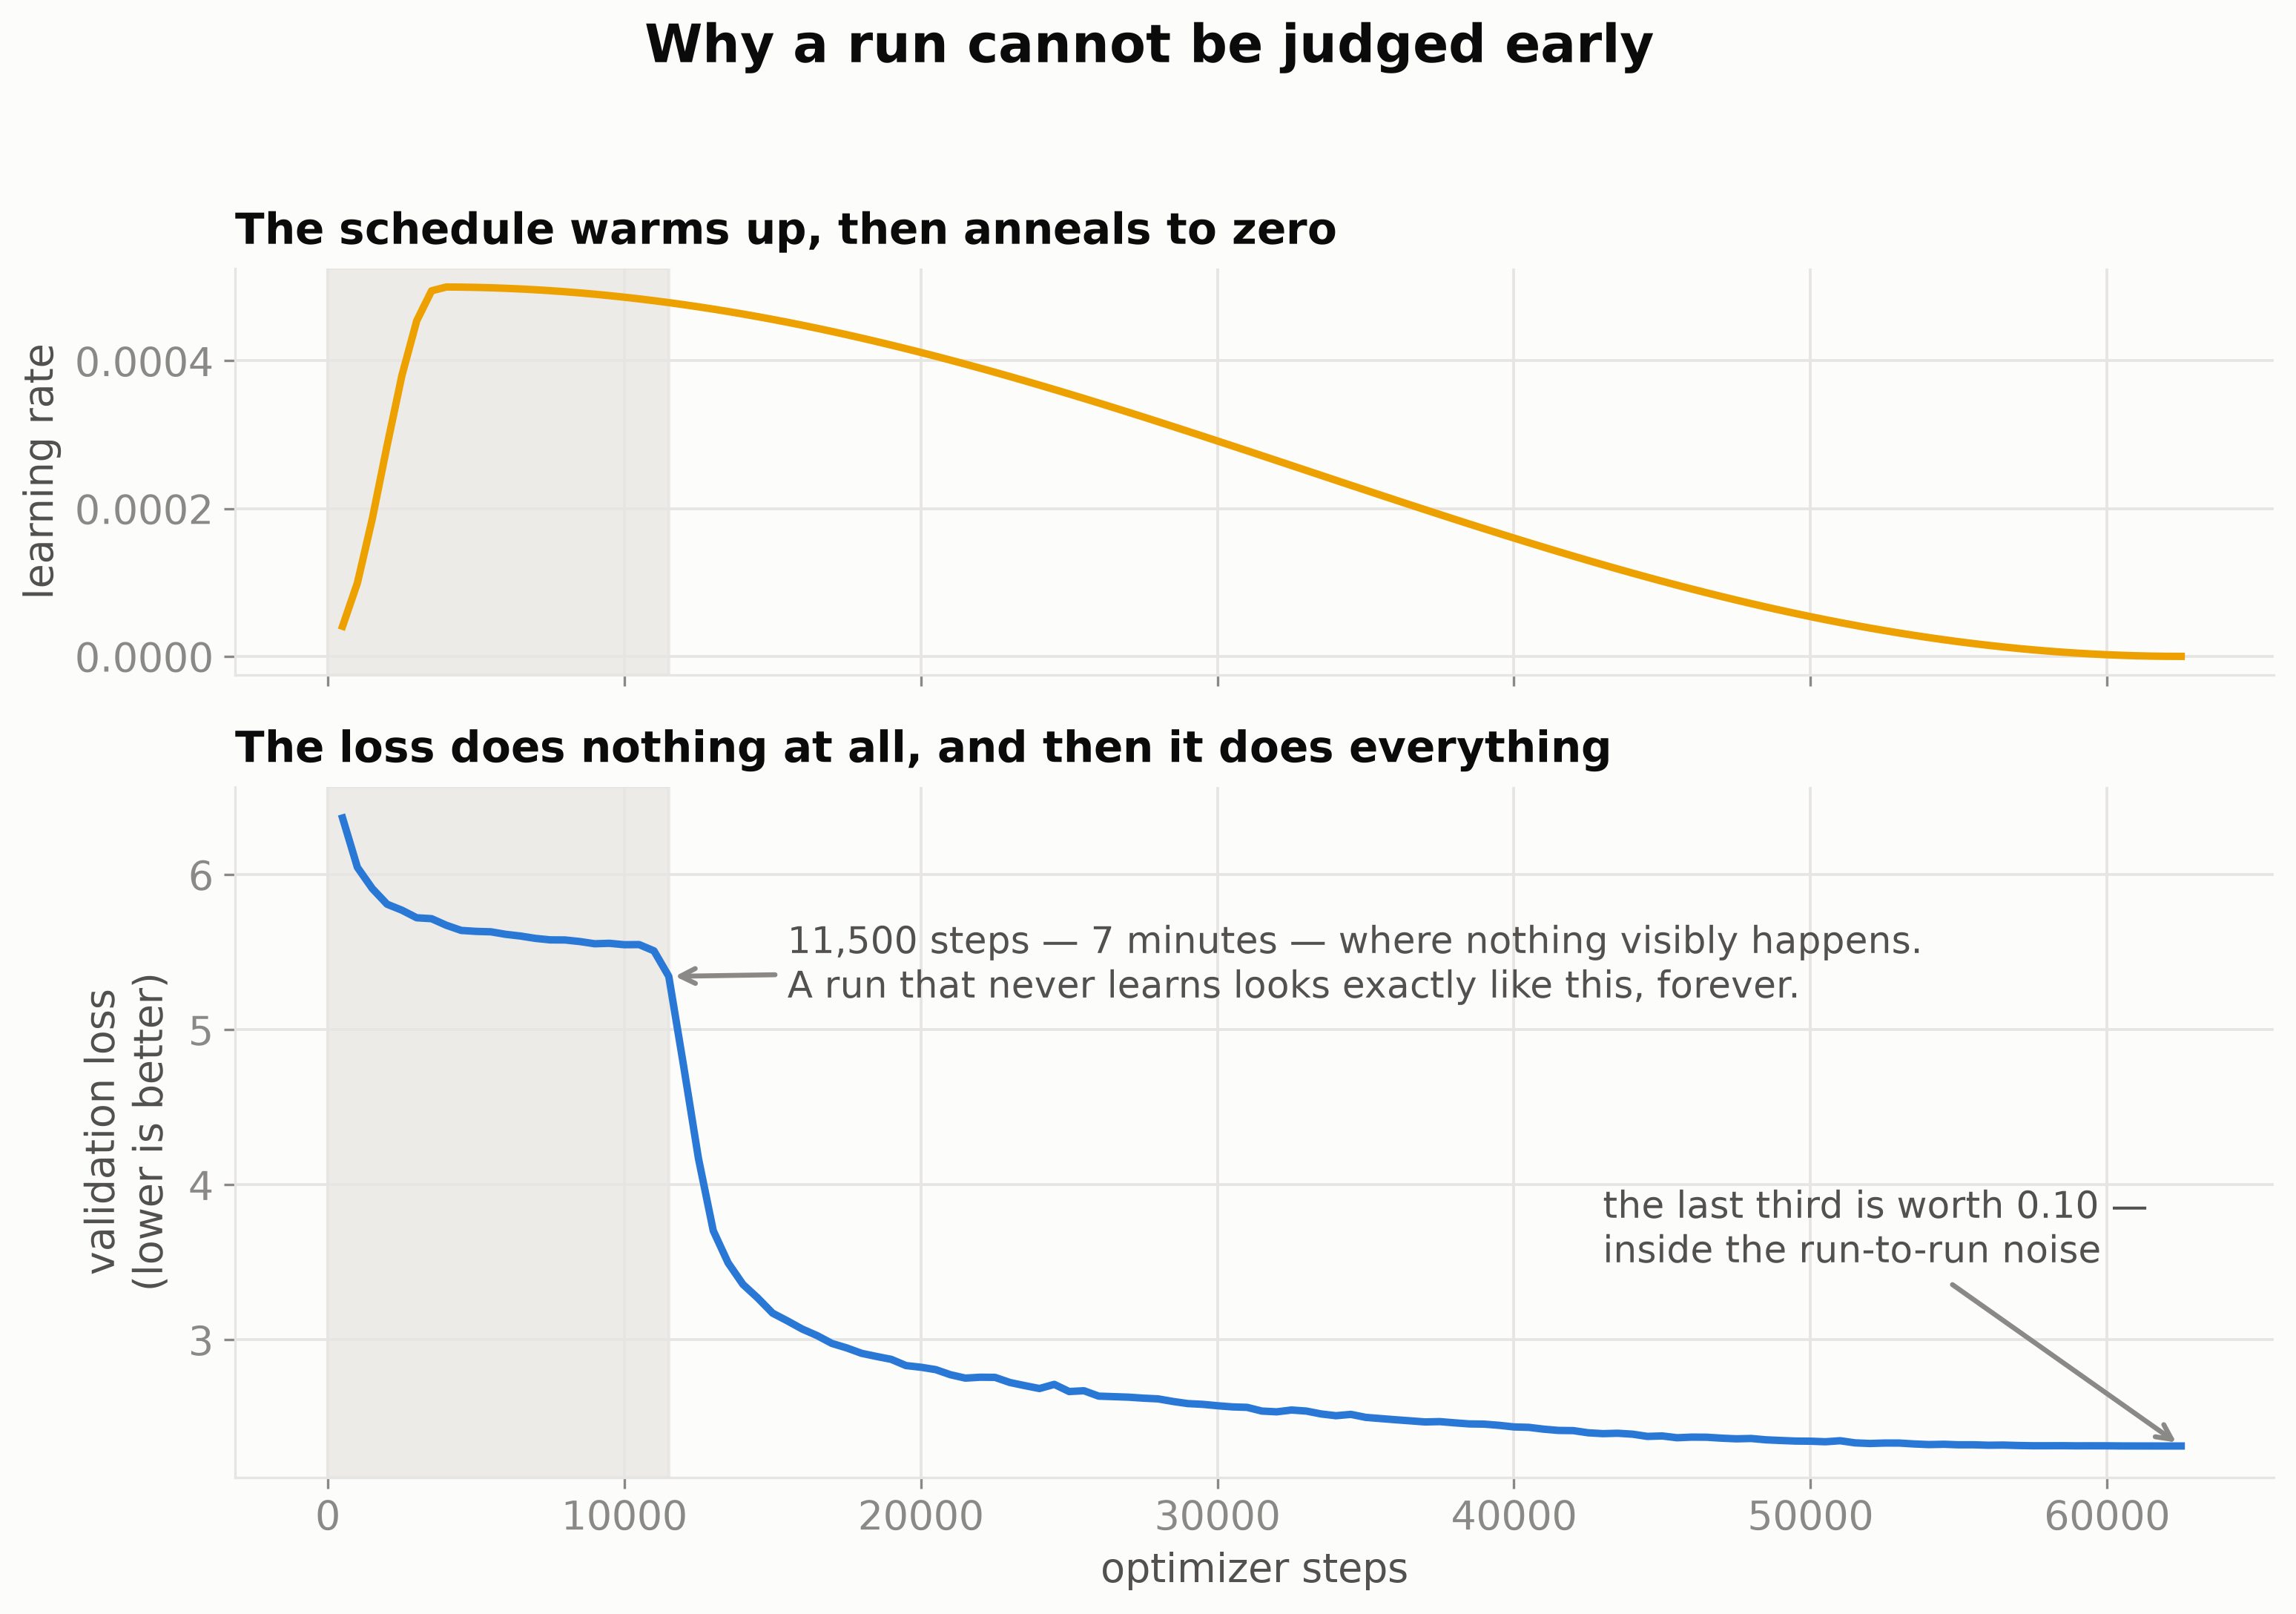

In [12]:
# 3. Why not stop early: for the first sixth of a run, success and failure look identical.
curve = factory.curve('yor_64M_62.5k_s0')
v = [(r['step'], r['val']['loss'], r['elapsed'] / 60) for r in curve]

PLATEAU_END = 11_500
flat = [x for x in v if x[0] <= PLATEAU_END]
print(f'first {PLATEAU_END:,} steps ({flat[-1][2]:.0f} min): loss moves '
      f'{flat[0][1]:.2f} -> {flat[-1][1]:.2f}, a change of {flat[0][1]-flat[-1][1]:.2f}')
after = [x for x in v if x[0] > PLATEAU_END]
print(f'next {after[10][0]-PLATEAU_END:,} steps: {flat[-1][1]:.2f} -> {after[10][1]:.2f}')

cut = min(v, key=lambda x: abs(x[0] - 41_667))
print(f'\nthe last third is worth {cut[1]-v[-1][1]:.2f} of loss -- inside the run-to-run noise.')
print('So the tail could have been cut. The head could not, and the head is where the\n'
      'uncertainty lives: 31% of the large-model runs never left it.')

show('08-why-not-shorter')

### And more cards would not have helped

More cards finish a *queue* sooner. They never make one *run* shorter — and the thing we were
usually waiting for was one run.

a real 20-job night, 33.8 GPU-hours of work:

   1 cards    33.8 h
   2 cards    16.9 h
   5 cards     7.0 h
  10 cards     3.7 h
  20 cards     2.2 h
  24 cards     2.2 h

the longest single job is 130 min = 2.2 h -- no number of cards goes below it


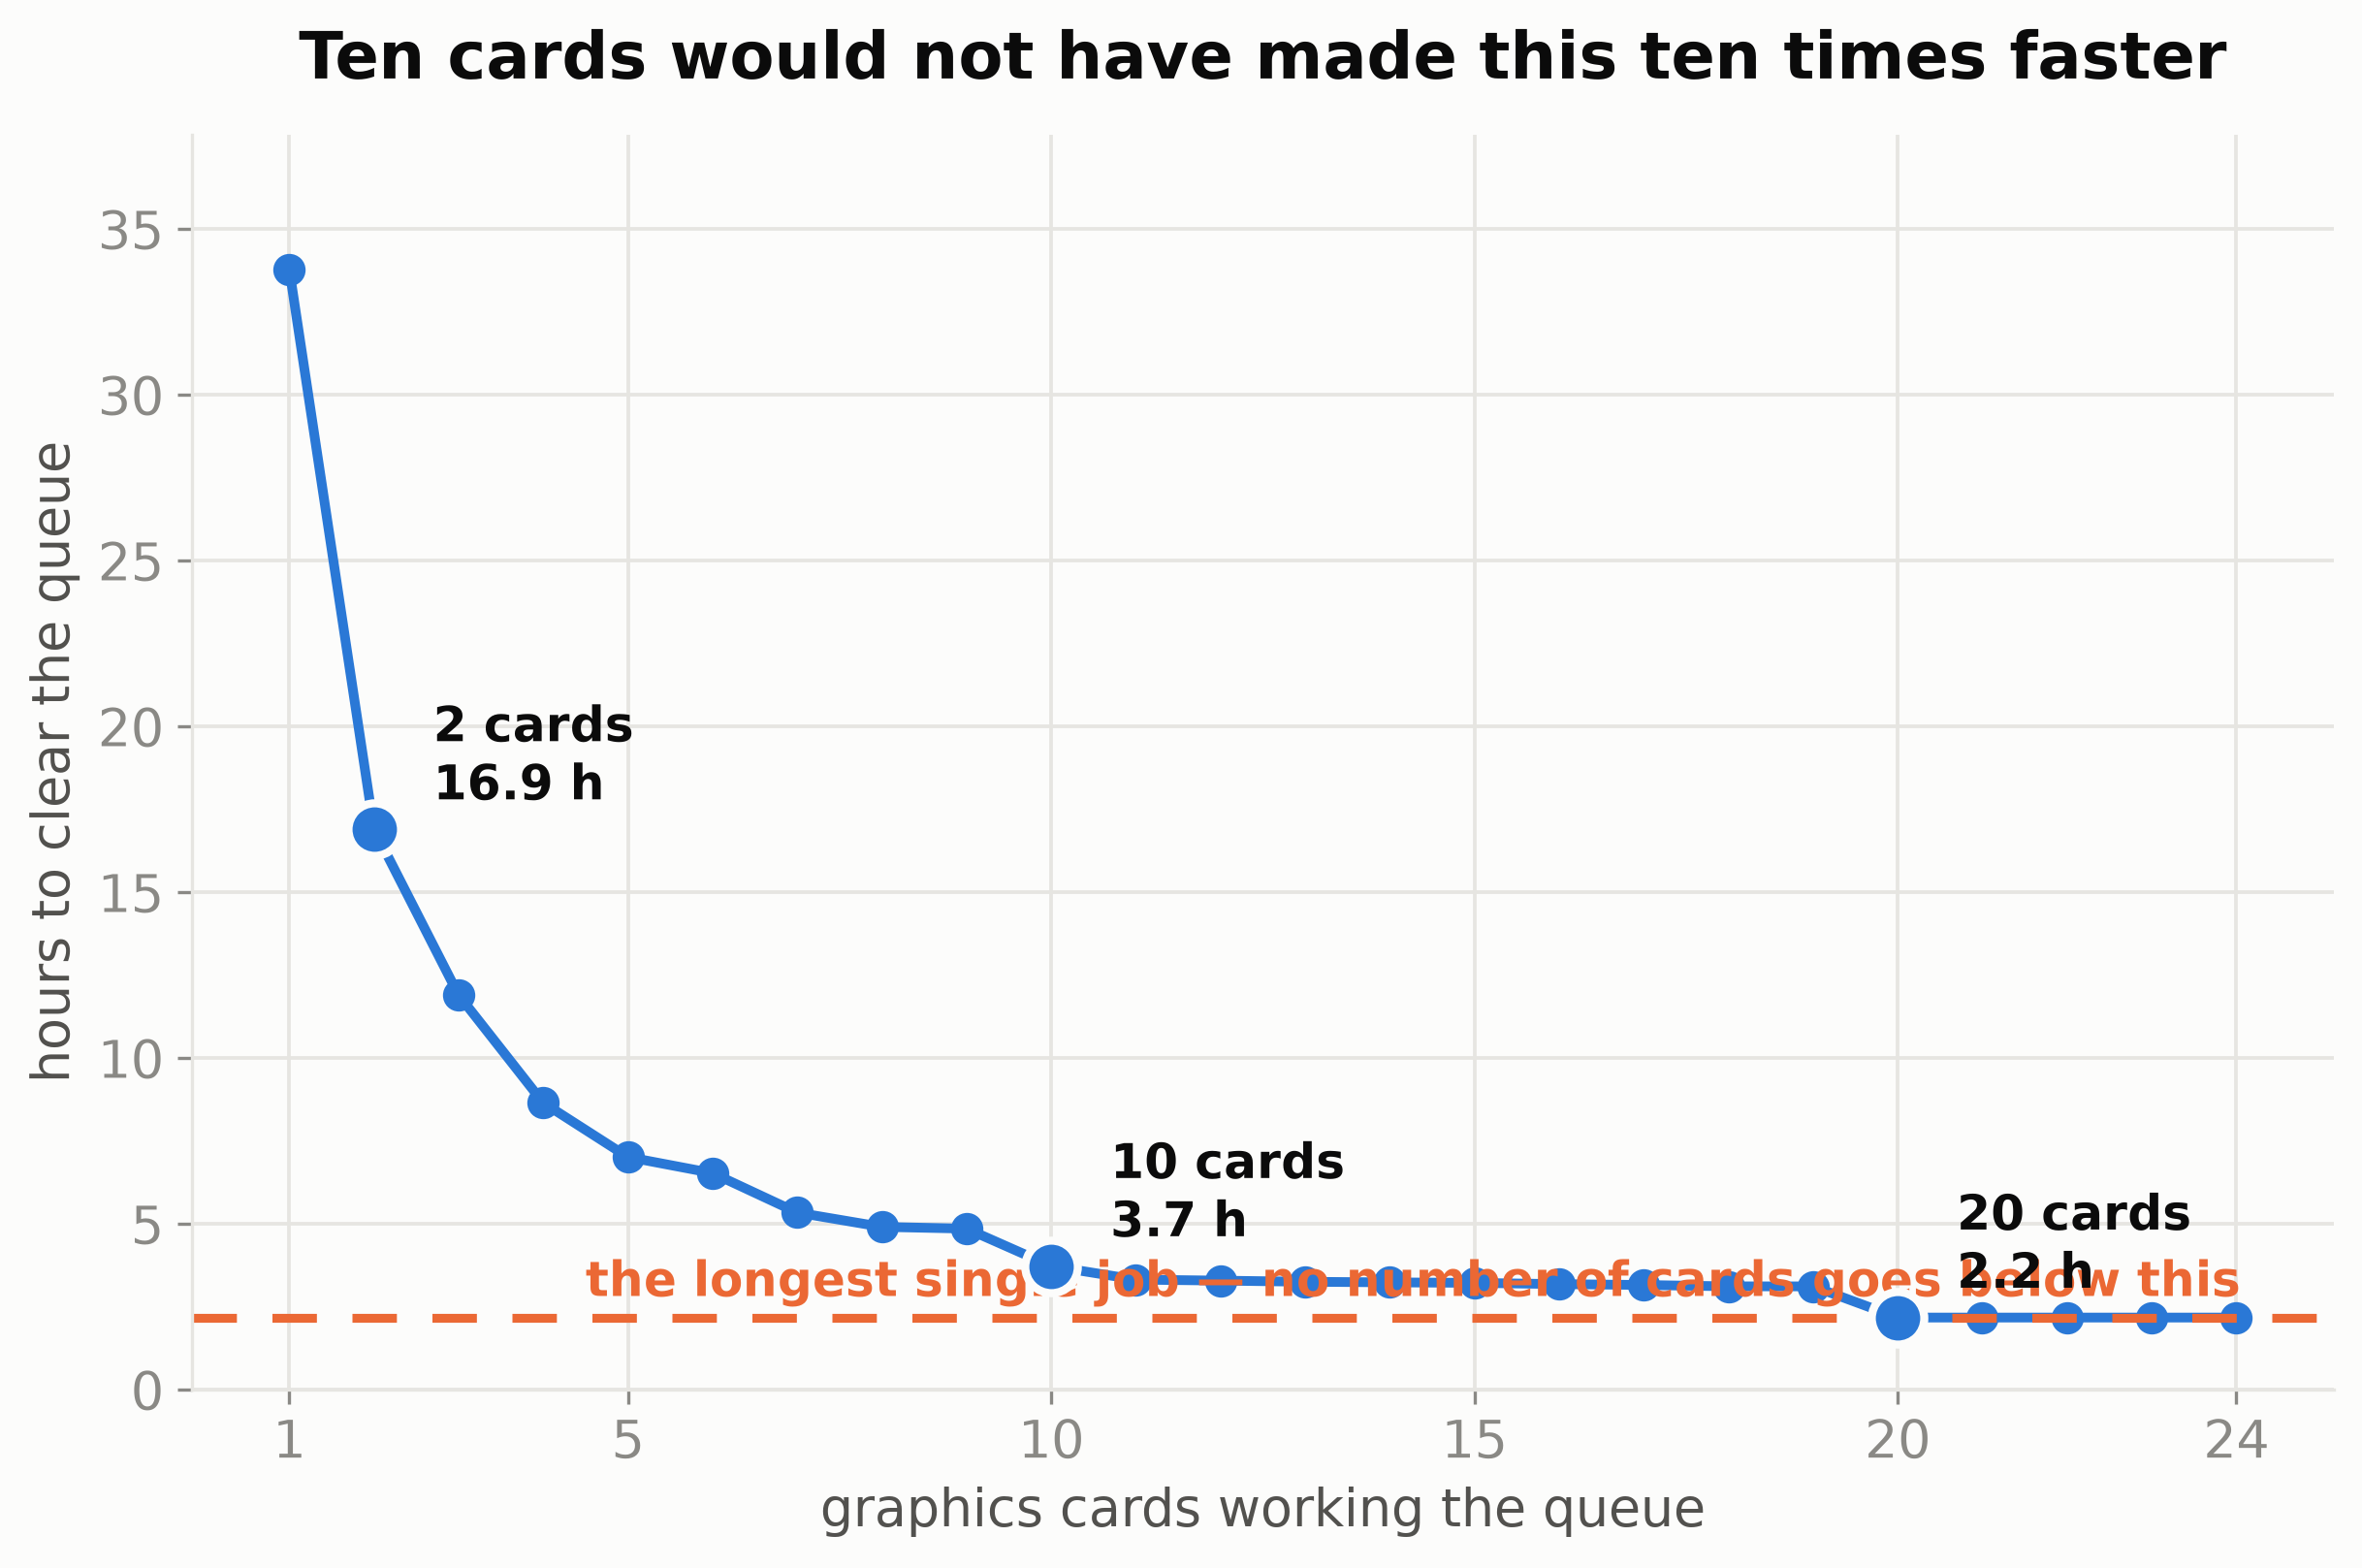

In [13]:
jobs = sorted((r['seconds'] / 60 for r in PRE if r['steps'] == 62_500), reverse=True)[:20]


def makespan(n):
    """Longest-first onto n cards, which is the ordering the scheduler actually uses."""
    cards = [0.0] * n
    for j in jobs:
        i = min(range(n), key=lambda k: cards[k])
        cards[i] += j
    return max(cards)


print(f'a real {len(jobs)}-job night, {sum(jobs)/60:.1f} GPU-hours of work:\n')
for n in (1, 2, 5, 10, 20, 24):
    print(f'  {n:>2} cards   {makespan(n)/60:>5.1f} h')
print(f'\nthe longest single job is {jobs[0]:.0f} min = {jobs[0]/60:.1f} h -- '
      'no number of cards goes below it')

show('09-scaling-with-cards')

---
## Panel 10b — What it cost

Cost is usually left out of student projects, which is a shame — it decides what you are allowed
to attempt. Hardware prices are current market figures; everything else is measured.

graphics-card time           143.3 GPU-hours
electricity, cards            43.0 kWh
electricity, at wall          68.8 kWh   = $6.88
renting the same time              $      430
buying the workstation             $   28,000

owning pays for itself at 9,333 GPU-hours. We used 143.
utilization over ~3 weeks of two cards: 14%
pretraining alone: 132.5 GPU-hours (92% of the total)


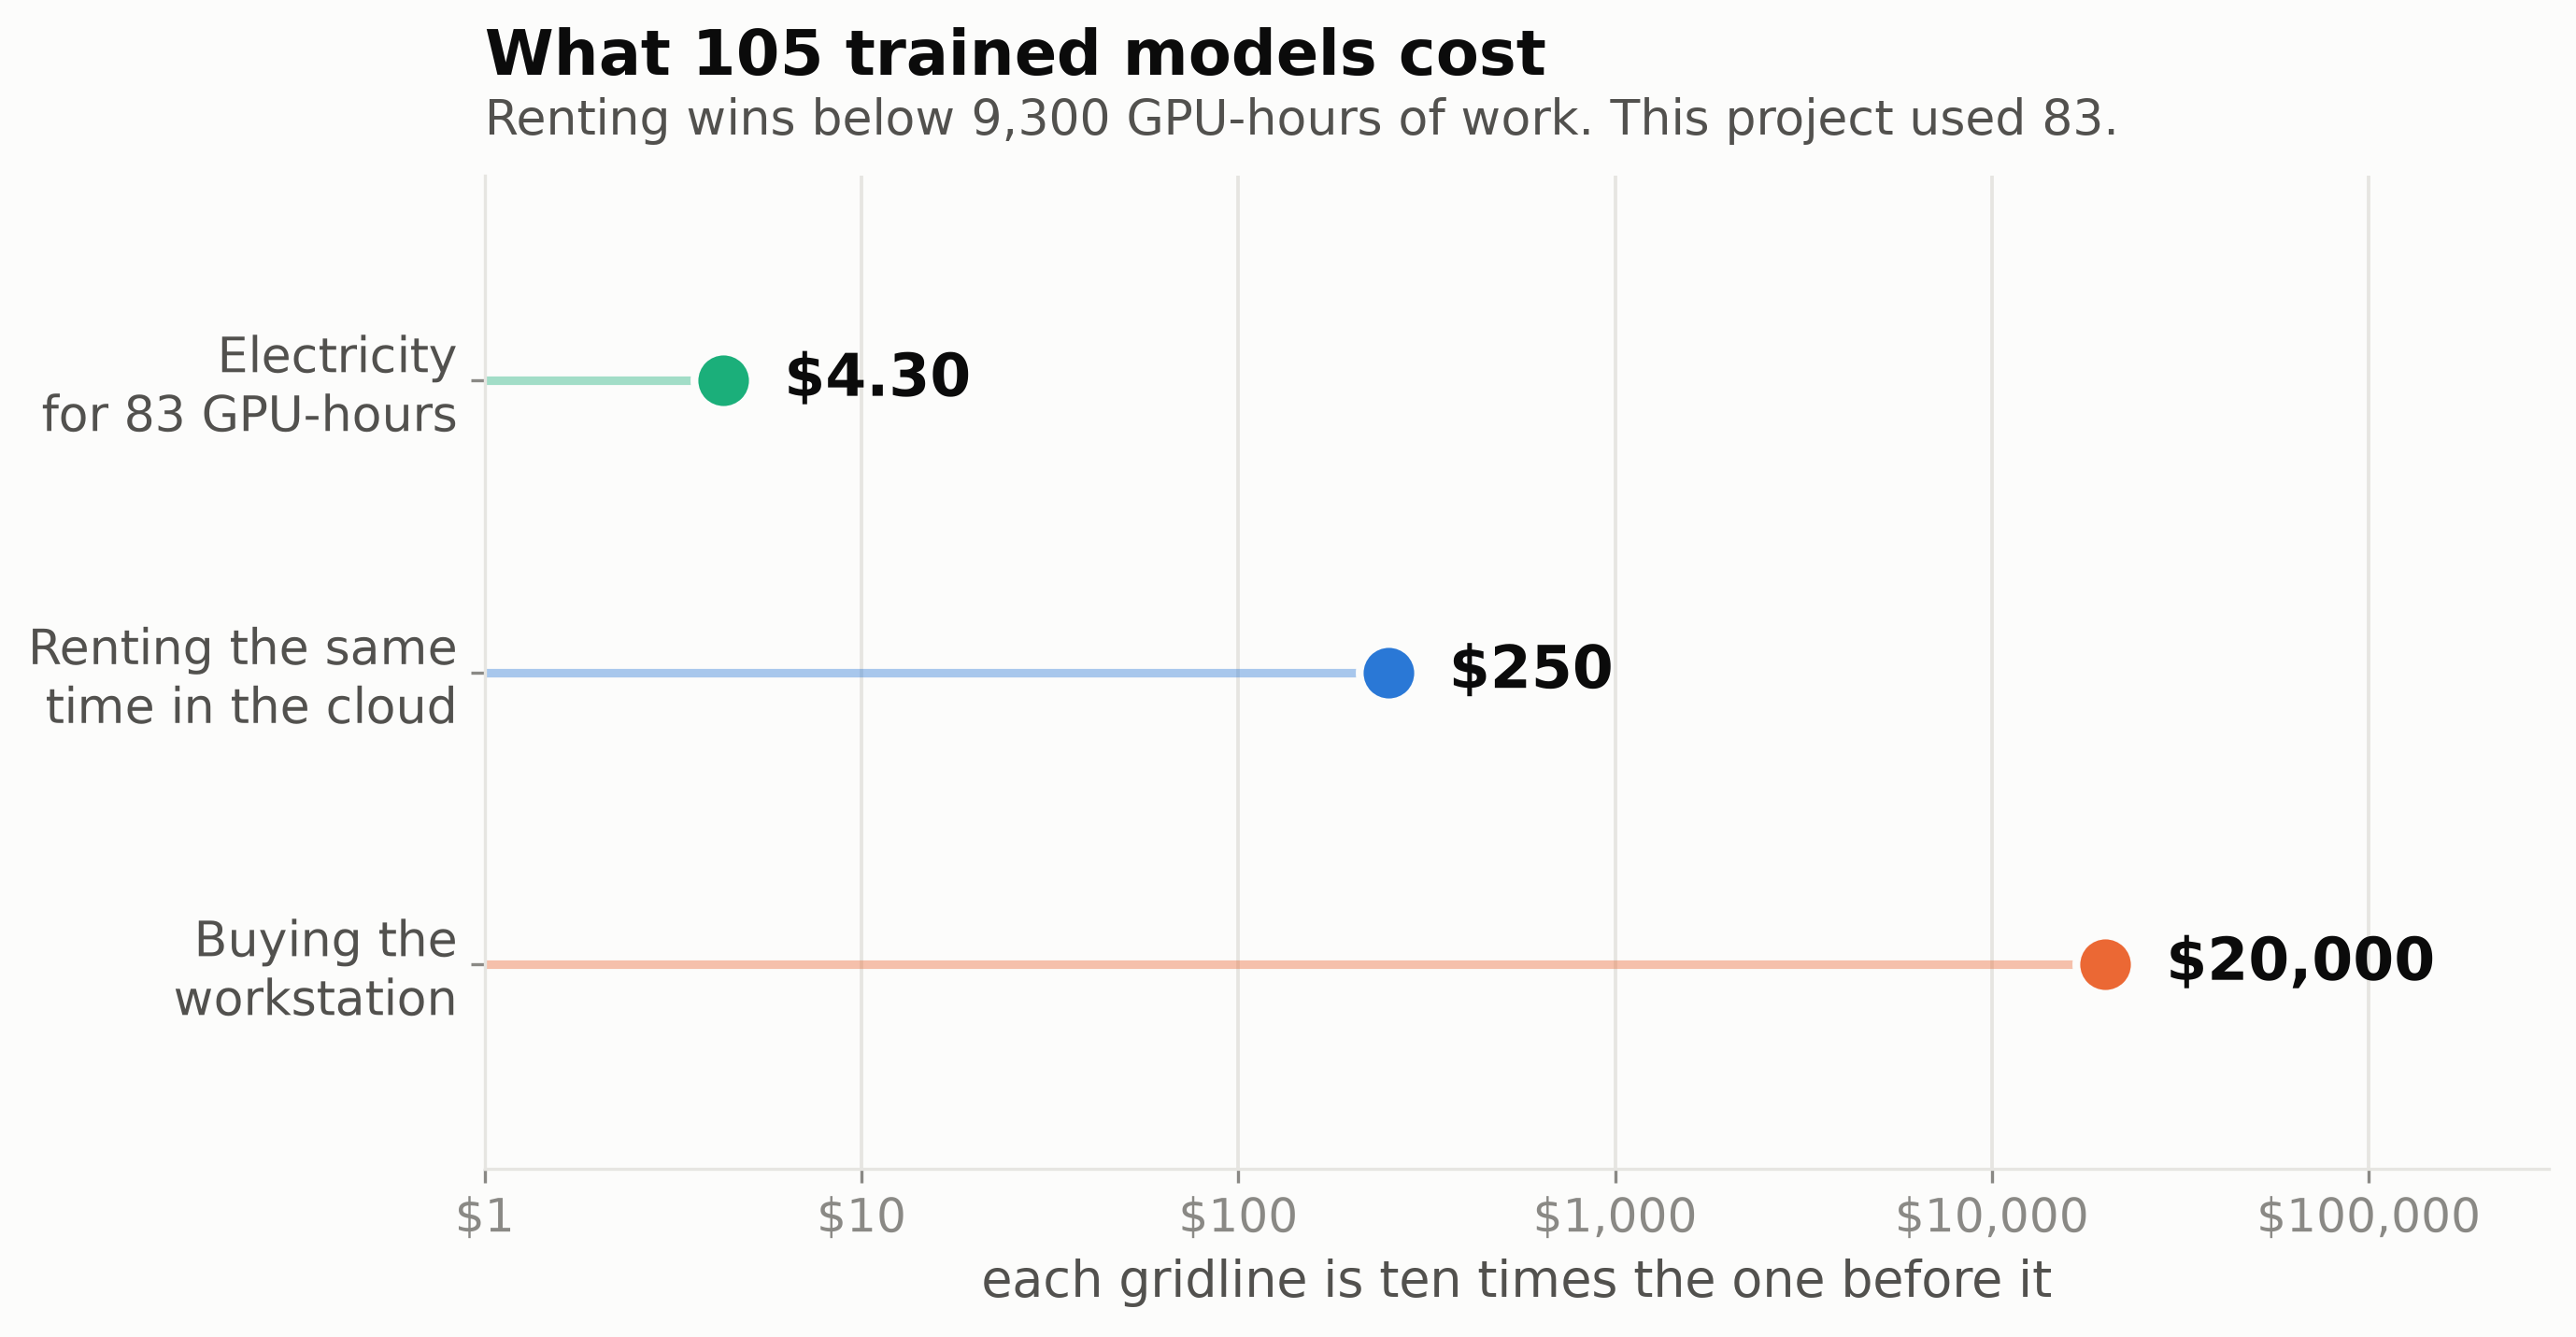

In [14]:
# --- market prices, the only inputs here that are not measured -------------------------------
CARD_PRICE, N_CARDS, MACHINE_EXTRA = 12_000, 2, 4_000
CLOUD_PER_GPU_HOUR = 3.00
KWH_PRICE = 0.10
CARD_WATTS = 300                      # the enforced power limit, measured at the
                                      # wall under load -- not the 325 nameplate
WALL_FACTOR = 1.6                     # cooling and the rest of the box

gpu_hours = sum(r['seconds'] for r in PRE) / 3600
gpu_hours += sum((r.get('seconds_per_seed') or 0) * len(r.get('scores') or [])
                 for r in DOWN) / 3600
kwh_cards = gpu_hours * CARD_WATTS / 1000
kwh_wall = kwh_cards * WALL_FACTOR
capex = CARD_PRICE * N_CARDS + MACHINE_EXTRA

print(f'graphics-card time      {gpu_hours:>10.1f} GPU-hours')
print(f'electricity, cards      {kwh_cards:>10.1f} kWh')
print(f'electricity, at wall    {kwh_wall:>10.1f} kWh   = ${kwh_wall*KWH_PRICE:,.2f}')
print(f'renting the same time   {"":>10} ${gpu_hours*CLOUD_PER_GPU_HOUR:>9,.0f}')
print(f'buying the workstation  {"":>10} ${capex:>9,.0f}')

crossover = capex / CLOUD_PER_GPU_HOUR
print(f'\nowning pays for itself at {crossover:,.0f} GPU-hours. We used {gpu_hours:.0f}.')
print(f'utilization over ~3 weeks of two cards: {100*gpu_hours/(24*21*2):.0f}%')
claim('GPU-hours, total', gpu_hours, 'What that bought in hours.** The project spent')
# Section 8 quotes pretraining-only time, which is a different number and should be.
# Pretraining-only hours are not quoted separately in report 09 -- the board quotes the
# total. Kept as a computed figure without an anchor so it still prints, rather than
# pointed at an unrelated sentence and reported as drift forever.
PRETRAIN_HOURS = sum(r['seconds'] for r in PRE) / 3600
print(f'pretraining alone: {PRETRAIN_HOURS:.1f} GPU-hours '
      f'({100*PRETRAIN_HOURS/gpu_hours:.0f}% of the total)')
claim('own-vs-rent crossover', crossover, 'roughly six and a half months')

show('06-what-it-cost')


### And what the data itself weighs

In [15]:
def dir_gb(path):
    return sum(os.path.getsize(os.path.join(r, f))
               for r, _, fs in os.walk(path) for f in fs) / 1024 ** 3


for label, path in (('prepared text', 'data'), ('checkpoints and logs', 'runs'),
                    ('training logs', 'logs')):
    if os.path.isdir(path):
        print(f'{label:<24} {dir_gb(path):>7.1f} GB')

# uint16 vs uint32 is a decision, not a default -- the vocabulary reaches down to the disk.
for c in ('yor', 'yor_xlmr'):
    s = json.load(open(f'data/{c}/stats.json', encoding='utf-8'))
    print(f"\n{c:<10} vocab {s['vocab_size']:>7,}  {s['store_bytes']} bytes/token  "
          f"{dir_gb(f'data/{c}'):.2f} GB for the same text")

prepared text                5.1 GB
checkpoints and logs       165.8 GB
training logs                0.0 GB

yor        vocab  16,000  2 bytes/token  0.15 GB for the same text

yor_xlmr   vocab 250,002  4 bytes/token  0.49 GB for the same text


---
## Panel 4 — More data stops helping, and stops early

The English ladder. This is the result we could never have got on Yoruba, because Yoruba does not
have more text — which is exactly why English is in the study.

,tokens,n_seeds,val_loss,spread
0,4M,3,3.621,0.333
1,16M,3,2.544,0.179
2,64M,3,2.282,0.115
3,256M,3,2.387,0.154
4,1024M,3,2.362,0.146


from 64M to 1024M -- 16x more text -- the loss moves -0.080
the run-to-run spread on this ladder is 0.185, so that is 0.43x the noise


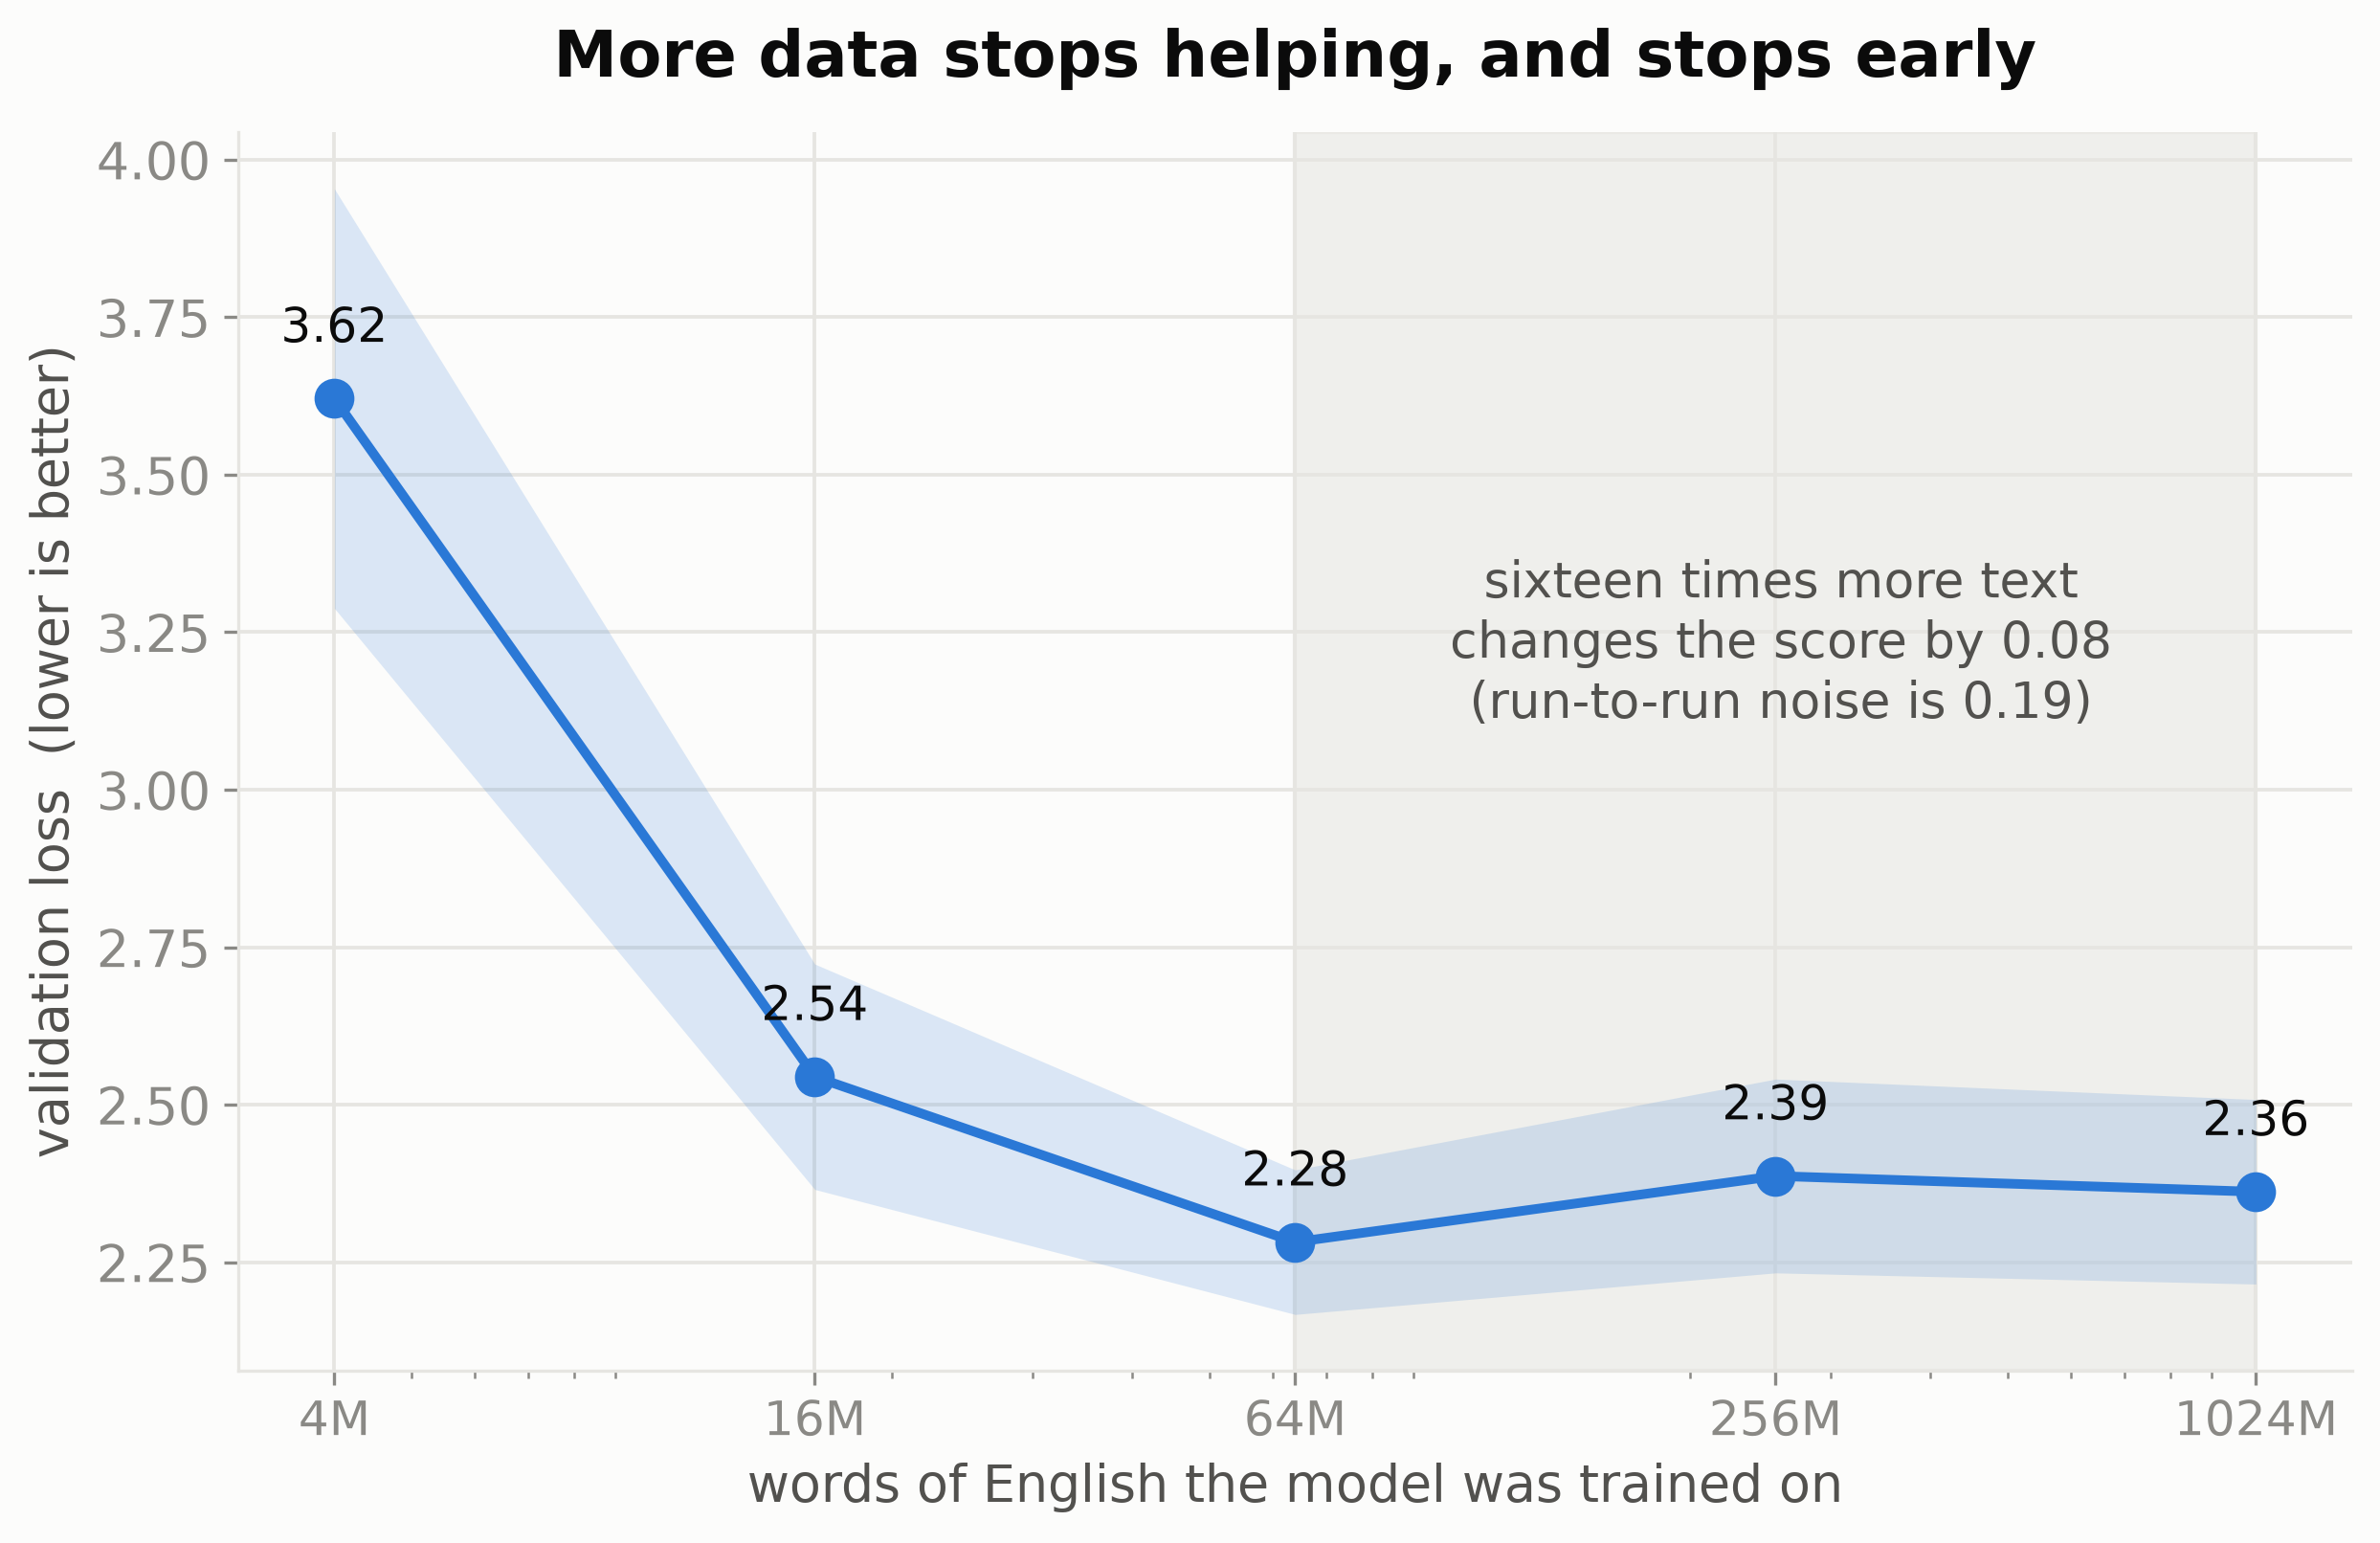

In [16]:
ladder = collections.defaultdict(list)
for r in PRE:
    if r.get('corpus') == 'eng_1b' and (r.get('preset') or 'poc') == 'poc' and r['steps'] == 62500:
        ladder[r['n_tokens']].append(r['val_loss'])

xs = sorted(ladder)
rung = [{'tokens': f'{factory.compact(n)}', 'n_seeds': len(ladder[n]),
         'val_loss': round(st.mean(ladder[n]), 3),
         'spread': round(st.stdev(ladder[n]), 3) if len(ladder[n]) > 1 else None}
        for n in xs]
display(pd.DataFrame(rung))

gain = st.mean(ladder[xs[-3]]) - st.mean(ladder[xs[-1]])
spread = st.mean(st.stdev(v) for v in ladder.values() if len(v) > 1)
print(f'from {factory.compact(xs[-3])} to {factory.compact(xs[-1])} -- 16x more text -- '
      f'the loss moves {gain:+.3f}')
print(f'the run-to-run spread on this ladder is {spread:.3f}, so that is {abs(gain)/spread:.2f}x '
      'the noise')
claim('16x more text buys', gain, 'moves the loss')

show('05-data-saturation')

---
## Panel 13 — What the factory could work out about itself

Every panel above is the factory answering a question about *language*. This one is the factory
answering a question about **training**, from nothing but its own 105 stored loss curves. No GPU
is touched by this cell.

**Should we build an early-abandon detector?** Thirteen runs never learned anything and burned
16% of everything we spent. The answer turns out to be no, and the interesting part is *why*.

197 runs with curves: 162 learned, 35 never did
25.5 GPU-hours wasted on runs that never learned (19% of all compute)

    step   runs               learned         never learned  overlap
     500    179         3.01 (min 2.01)         2.83 (max 3.63)      yes
   2,000    190         3.50 (min 2.44)         3.34 (max 3.98)      yes
   4,000    183         4.03 (min 2.57)         3.45 (max 4.04)      yes
   8,000    184         5.18 (min 3.22)         3.56 (max 4.26)      yes
  12,000     87         3.80 (min 3.24)         3.37 (max 3.40)      yes
  24,000     85         4.46 (min 3.14)         3.03 (max 3.53)      yes

A clean split at any checkpoint? NO -- they overlap everywhere


,wait until,saved (GPU-h),lost (GPU-h),net (GPU-h),doomed caught,good runs killed
0,0.1,22.9,107.0,-84.1,35,162
1,0.2,20.4,102.3,-81.9,35,152
2,0.3,17.8,95.5,-77.7,35,130
3,0.4,15.3,72.2,-56.9,35,84
4,0.5,12.0,48.0,-36.1,34,50



Best operating point available: wait 50%, net -36.1 GPU-hours. Every point is negative.

Why it is structural rather than a tuning failure:
  only 18% of runs are doomed;
  a doomed run wastes at most its REMAINING time,
  a false kill wastes a WHOLE run that then has to be redone.


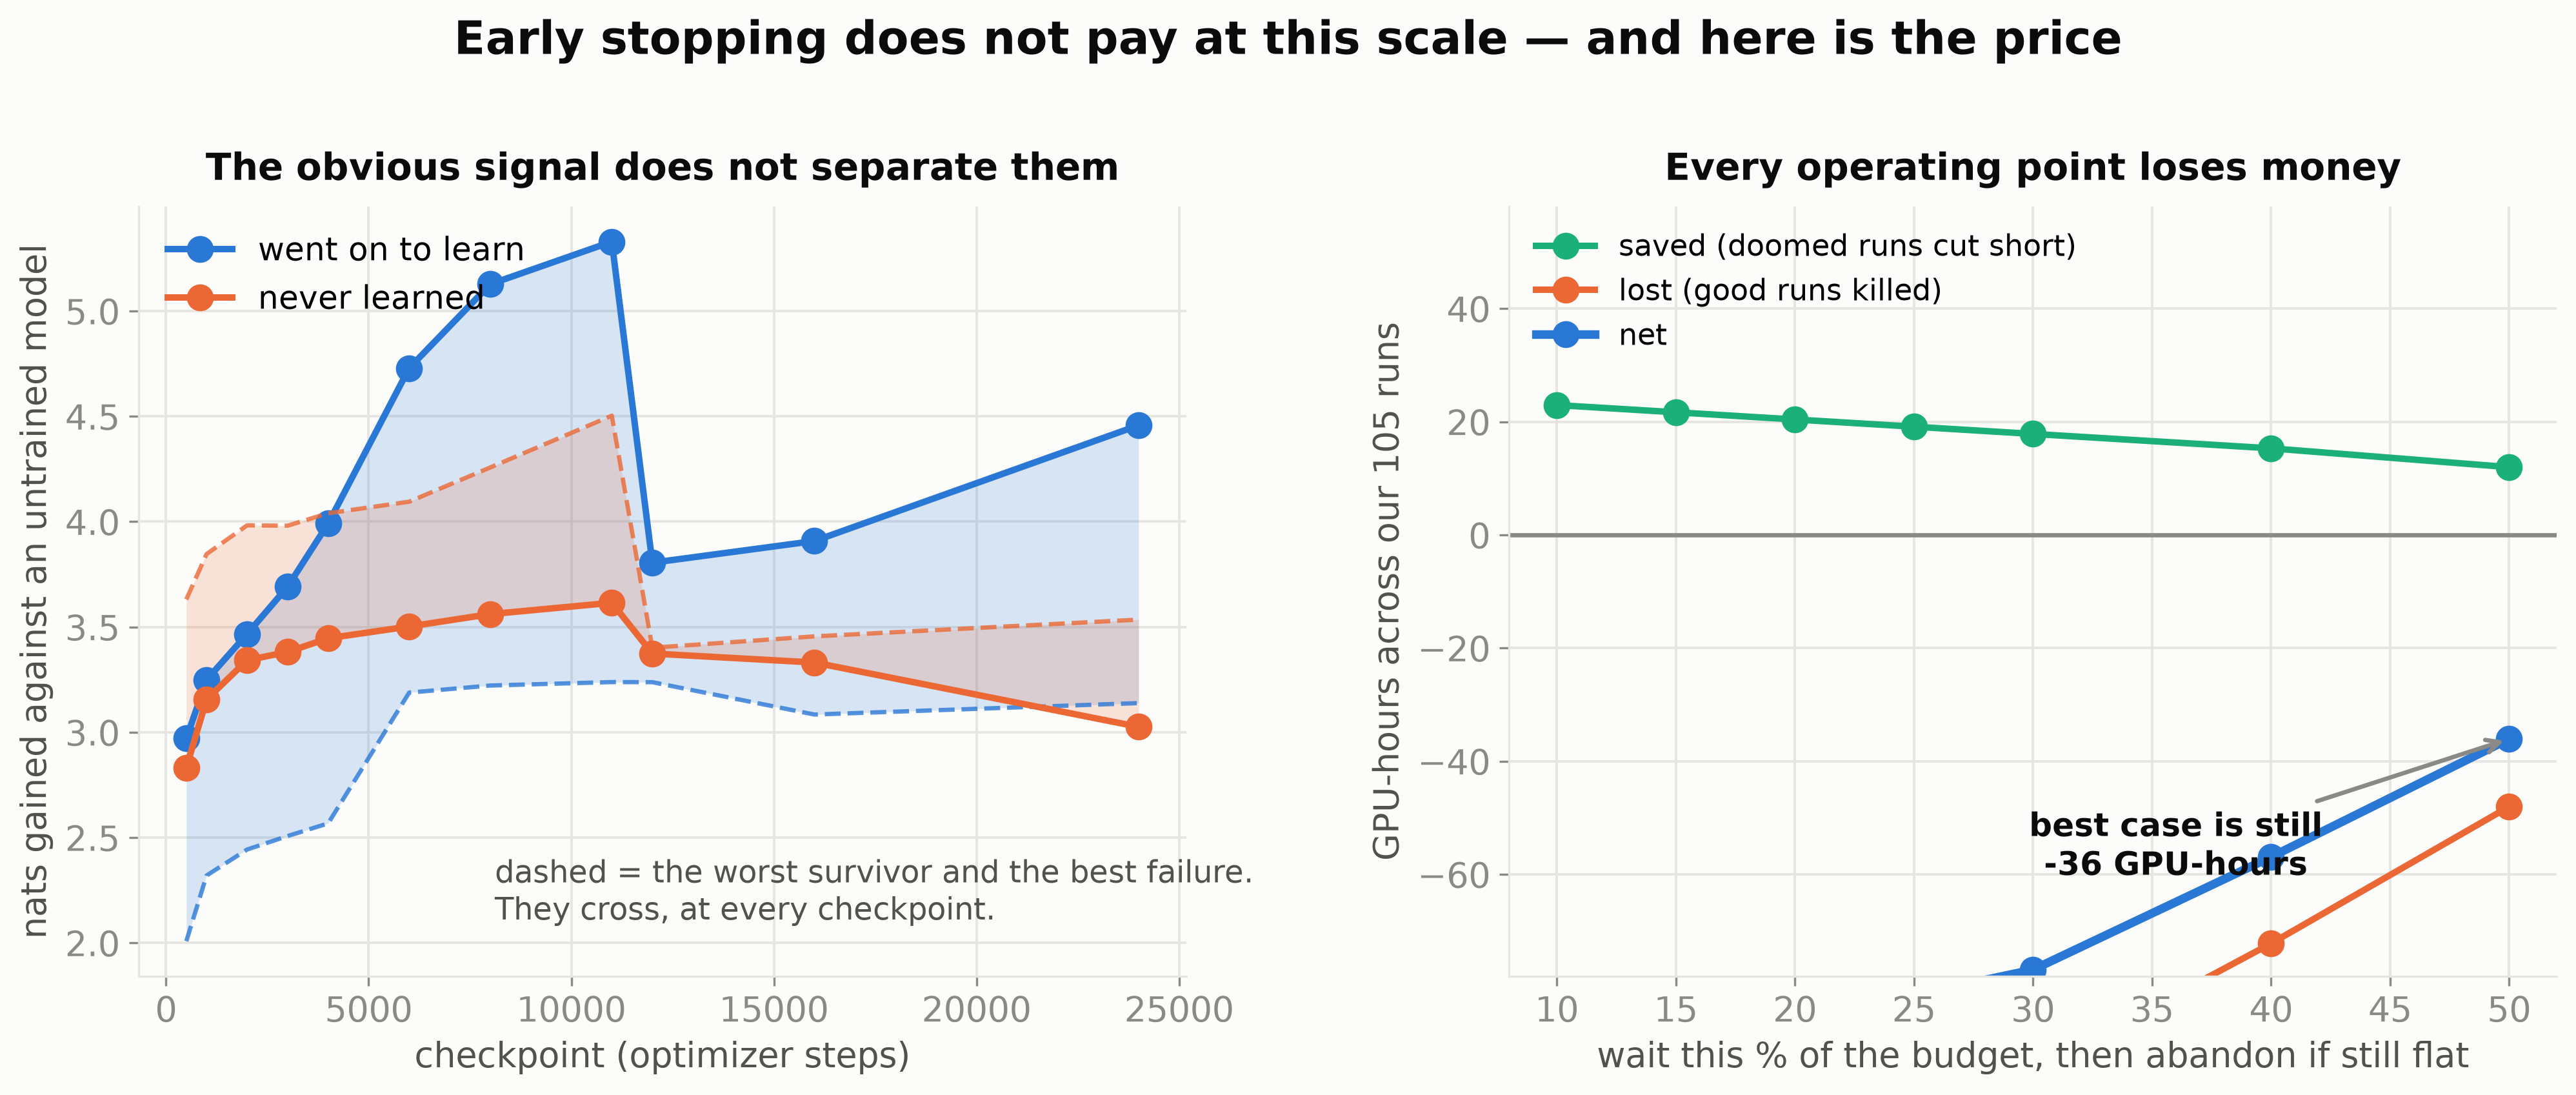

In [17]:
import early_signal

runs = early_signal.load()
dead = [r for r in runs if r['dead']]
wasted = sum(r['seconds'] for r in dead) / 3600
total = sum(r['seconds'] for r in runs) / 3600
print(f'{len(runs)} runs with curves: {len(runs)-len(dead)} learned, {len(dead)} never did')
print(f'{wasted:.1f} GPU-hours wasted on runs that never learned ({100*wasted/total:.0f}% of all compute)')

# Does the obvious feature -- how far the loss has fallen -- separate the two outcomes?
sep = early_signal.separation(runs, [500, 2000, 4000, 8000, 12000, 24000])
print('\nA clean split at any checkpoint?',
      'yes' if any(not s['overlap'] for s in sep) else 'NO -- they overlap everywhere')

# So price the rule that DOES discriminate: abandon if the run has not left its plateau.
pats = [early_signal.patience_rule(runs, d) for d in (0.10, 0.20, 0.30, 0.40, 0.50)]
display(pd.DataFrame(pats).rename(columns={
    'deadline': 'wait until', 'caught': 'doomed caught', 'false_kills': 'good runs killed',
    'saved_h': 'saved (GPU-h)', 'lost_h': 'lost (GPU-h)', 'net_h': 'net (GPU-h)'}).round(1))

best = max(pats, key=lambda x: x['net_h'])
print(f"\nBest operating point available: wait {best['deadline']:.0%}, net "
      f"{best['net_h']:+.1f} GPU-hours. Every point is negative.")
claim('best early-stopping outcome', best['net_h'],
      'The best operating point available nets')

print('\nWhy it is structural rather than a tuning failure:')
print(f'  only {100*len(dead)/len(runs):.0f}% of runs are doomed;')
print('  a doomed run wastes at most its REMAINING time,')
print('  a false kill wastes a WHOLE run that then has to be redone.')

show('10-early-signal')

In [18]:
# And the deadline could not be a constant anyway, because the cliff moves with the setup.
cliffs = [(r, early_signal.cliff_step(r)) for r in runs if not r['dead']]
cliffs = [(r, c) for r, c in cliffs if c]
vals = [c for _, c in cliffs]
print(f'{len(vals)} runs with a locatable cliff:  median {st.median(vals):,.0f} steps, '
      f'range {min(vals):,} to {max(vals):,}  ({max(vals)/min(vals):.0f}x)')

by = collections.defaultdict(list)
for r, c in cliffs:
    by[r['preset']].append(c)
for k in sorted(by):
    print(f'  {k:<10} n={len(by[k]):>3}  median {st.median(by[k]):>7,.0f} steps')
print('\nLearning rate and model size are perfectly confounded across our runs, so we cannot\n'
      'say which moves it. That is a real gap and a cheap experiment closes it.')

143 runs with a locatable cliff:  median 6,600 steps, range 2,200 to 48,500  (22x)
  afriberta  n= 37  median  31,500 steps
  poc        n=106  median   5,000 steps

Learning rate and model size are perfectly confounded across our runs, so we cannot
say which moves it. That is a real gap and a cheap experiment closes it.


---
## Week 7 — is your metric the right metric?

Every pretraining decision this term was made on validation loss, and it had never been checked
against whether the model is any *good* at anything. 107 checkpoints on disk, exactly one ever
fine-tuned. Checking it cost 2.3 GPU-hours because the pretraining was already paid for.


,task,n_all,pearson_all,n_trained,pearson_trained,spearman_trained
0,Topic classification,19,-0.616,16,-0.888,-0.800
1,Entity recognition,19,-0.935,16,0.303,0.159


entity recognition, the 16 trained models: r = +0.303, t = 1.19, df = 14
which is indistinguishable from zero. The claim is that the relationship is ABSENT,
not that it inverts -- asserting an inversion would be a claim the data cannot carry.


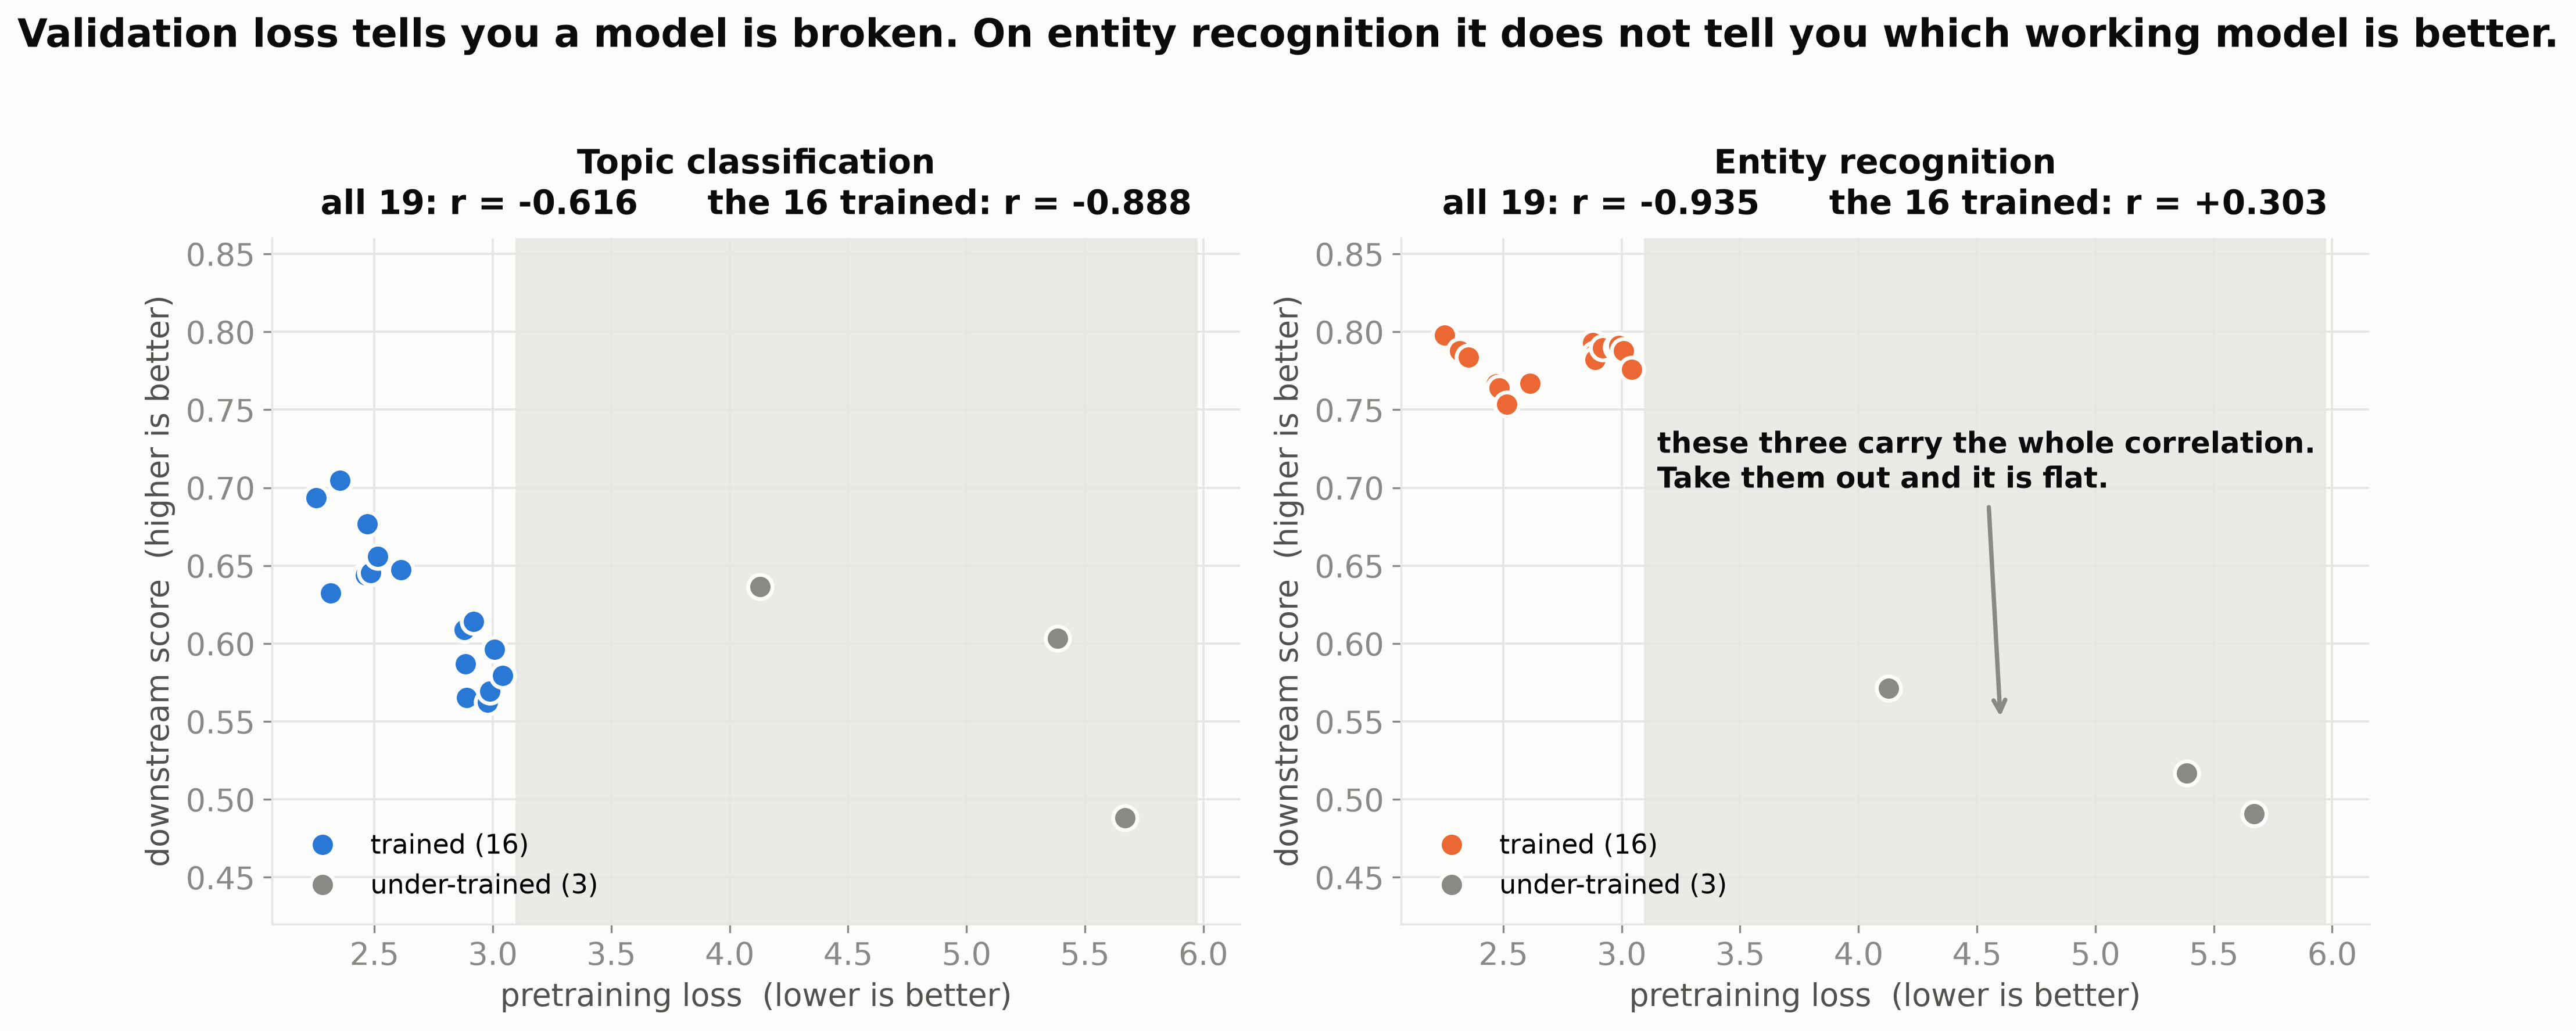

In [19]:
import study_downstream_correlation as corr

rows = json.load(open('runs/downstream_correlation.json', encoding='utf-8'))
CUT = 3.1        # below this a model trained; above it, it did not


def _rank(v):
    order = sorted(range(len(v)), key=lambda i: v[i])
    out = [0.0] * len(v)
    for pos, i in enumerate(order):
        out[i] = float(pos)
    return out


def pearson_spearman(g):
    x = [r['val_loss'] for r in g]
    y = [r['mean'] for r in g]
    return st.correlation(x, y), st.correlation(_rank(x), _rank(y))


summary = []
for task, label in (('sib200', 'Topic classification'), ('masakhaner', 'Entity recognition')):
    g = [r for r in rows if r['task'] == task]
    well = [r for r in g if r['val_loss'] < CUT]
    pa, sa = pearson_spearman(g)
    pw, sw = pearson_spearman(well)
    summary.append({'task': label, 'n_all': len(g), 'pearson_all': round(pa, 3),
                    'n_trained': len(well), 'pearson_trained': round(pw, 3),
                    'spearman_trained': round(sw, 3)})
display(pd.DataFrame(summary))

ner = [r for r in rows if r['task'] == 'masakhaner' and r['val_loss'] < CUT]
r_ner = pearson_spearman(ner)[0]
# Is +0.303 distinguishable from zero? It is not, and the panel has to say so rather than
# calling it a sign flip -- which is what the first draft did.
n = len(ner)
t_stat = r_ner * math.sqrt((n - 2) / (1 - r_ner ** 2))
print(f'entity recognition, the {n} trained models: r = {r_ner:+.3f}, t = {t_stat:.2f}, df = {n-2}')
print('which is indistinguishable from zero. The claim is that the relationship is ABSENT,')
print('not that it inverts -- asserting an inversion would be a claim the data cannot carry.')
claim('SIB correlation, trained only', pearson_spearman(
    [r for r in rows if r['task'] == 'sib200' and r['val_loss'] < CUT])[0],
    'r = \u22120.888')

show('11-metric-validity')

### Week 5 — why one task can be predicted and the other cannot

The first version of this blamed the floor: entity recognition starts closer to its ceiling, so
less is left for pretraining to supply. **That was wrong**, and it reached a figure and an email
before anyone checked it. The floors are near enough identical. What differs is how much the gain
*varies* between models.


,task,floor,floor % of best,every model gains,band width,band as % of smallest gain
0,Topic classification,0.429,61%,0.133,0.143,107%
1,Entity recognition,0.626,78%,0.128,0.044,35%


The floors are 61% and 78% of the best achieved -- 17 points apart, and that gap has moved twice.
The bands are 0.143 and 0.044, a factor of 3.2 -- and no choice of floor moves it.

A benefit that every model receives equally cannot be predicted by anything, because
there is nothing left to predict. That, not the floor, is the reason.


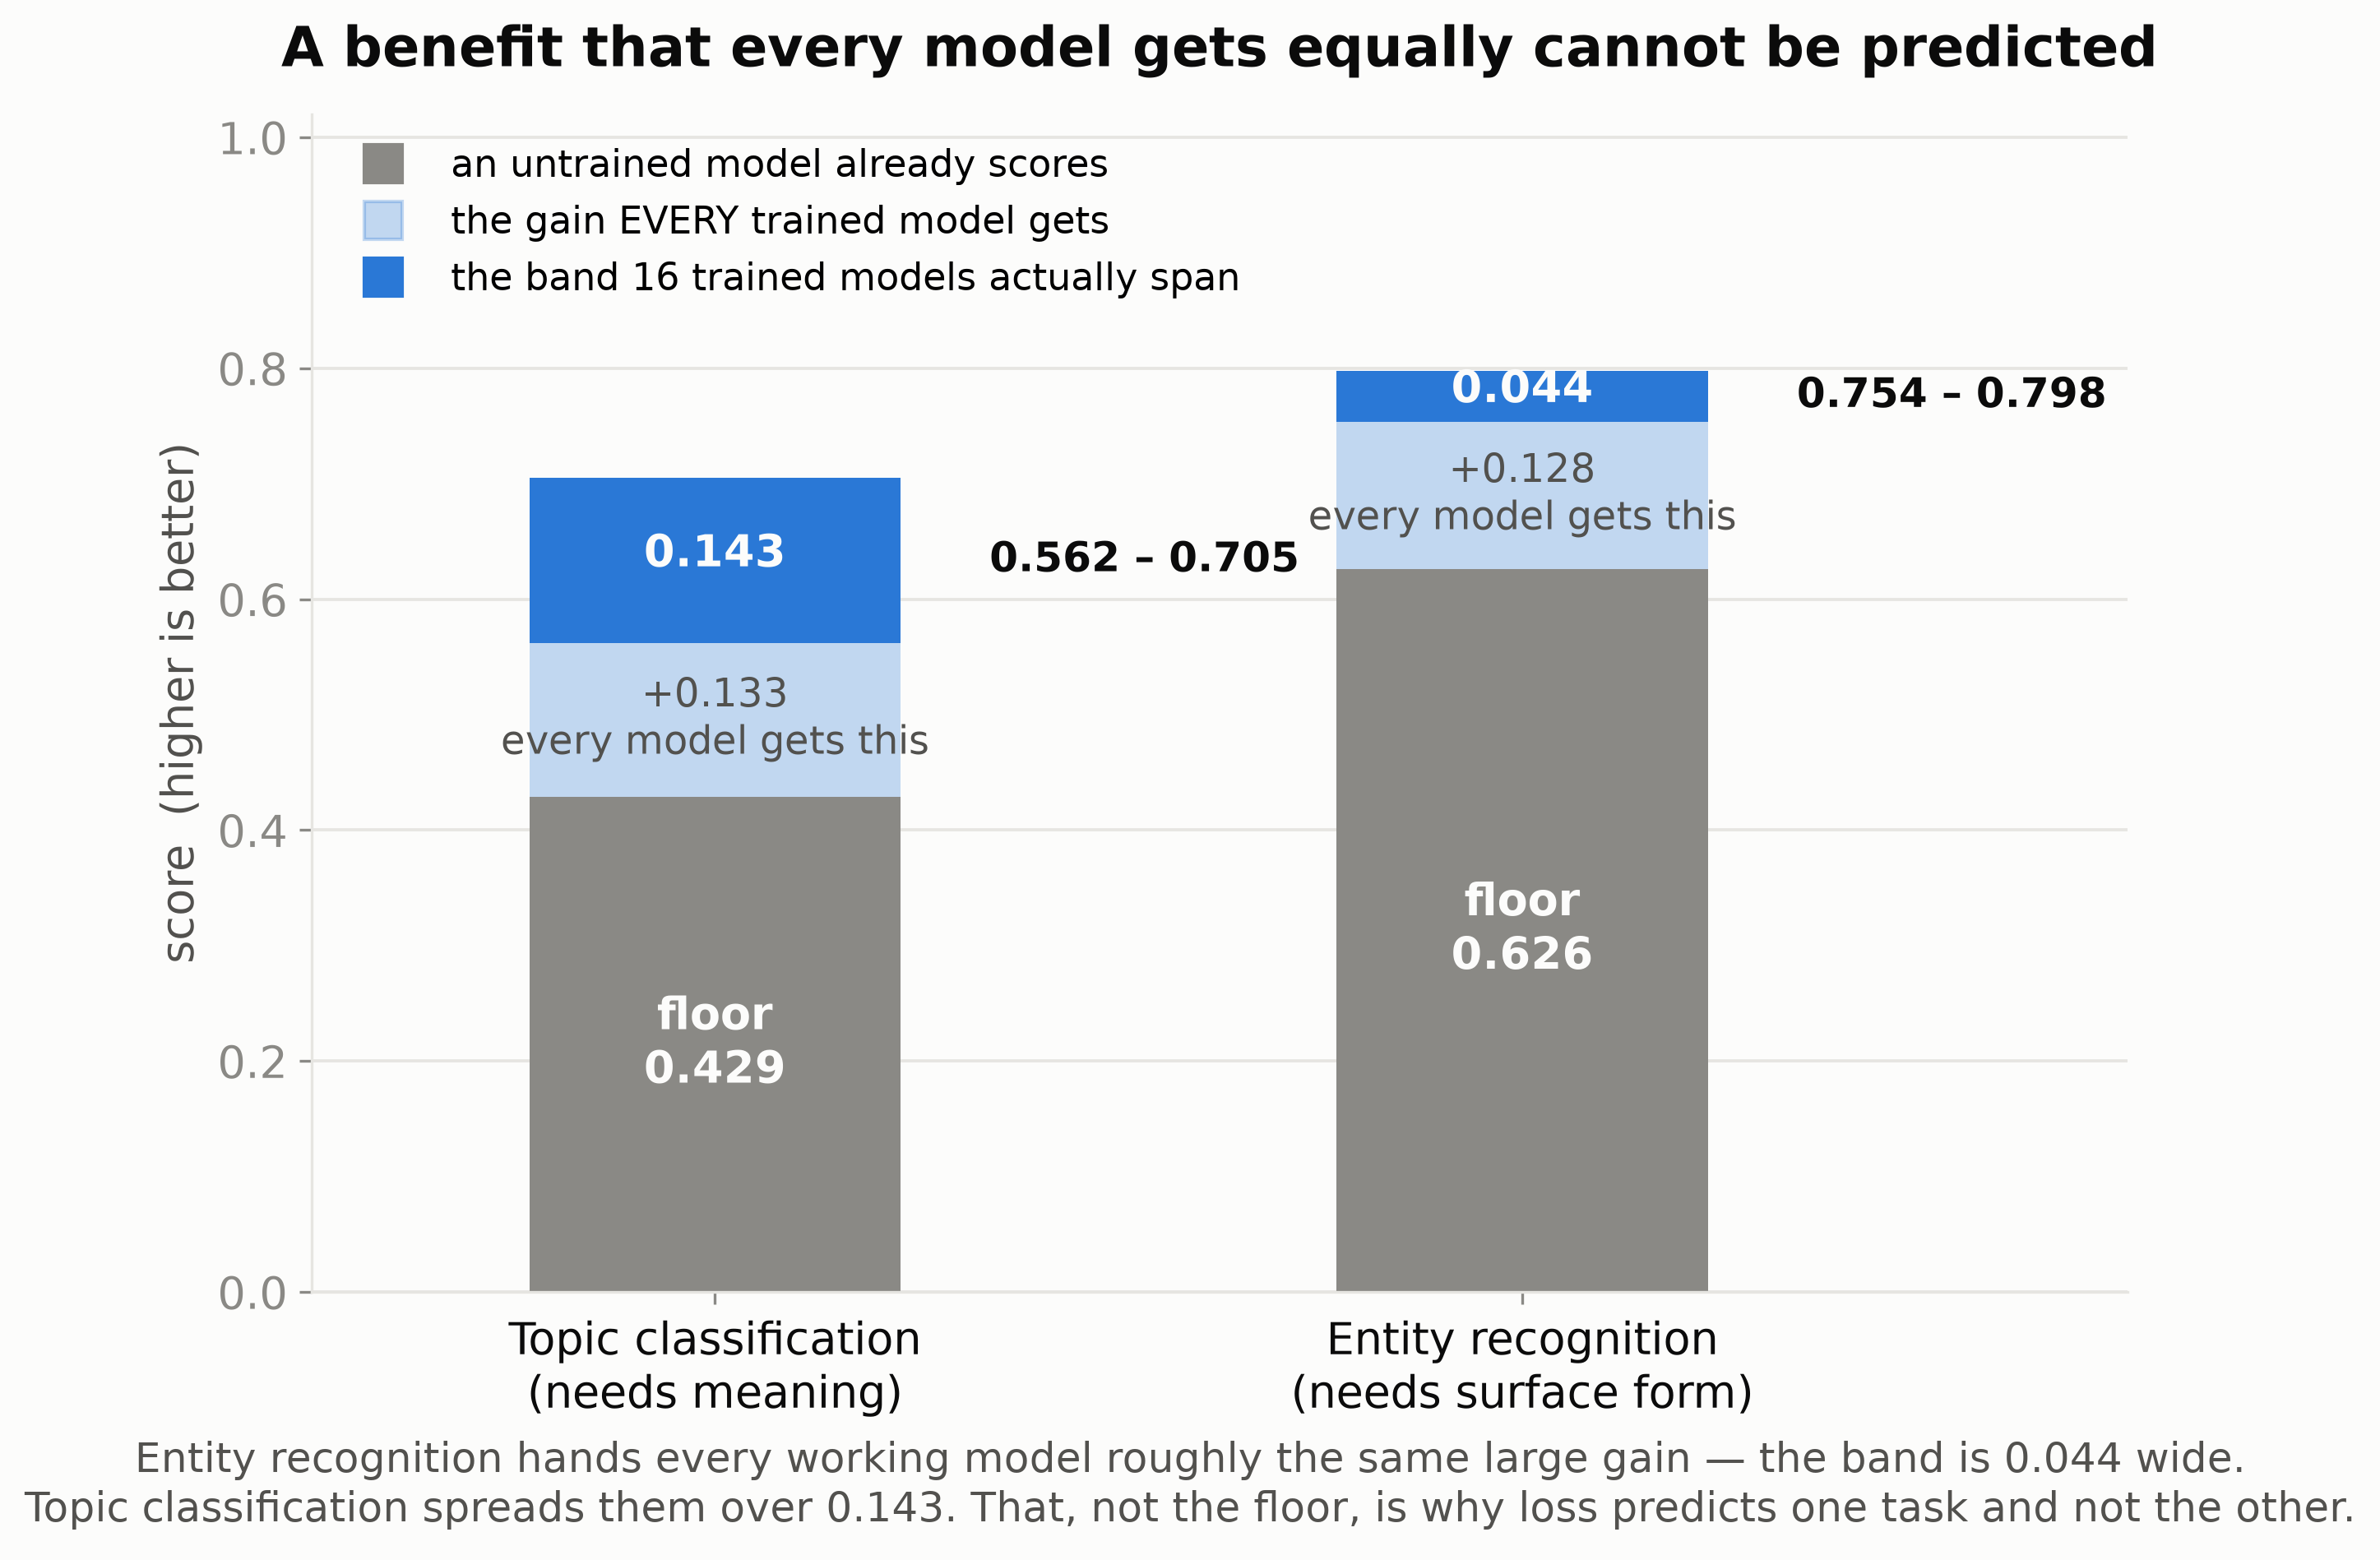

In [20]:
ft_rows = ft_api.results('*')
band = []
for task, steps, label in (('sib200', 1056, 'Topic classification'),
                           ('masakhaner', 2150, 'Entity recognition')):
    # n_train_requested is None means the FULL split, and that filter is load-bearing. The
    # label-quantity experiment runs this same untrained control at 701 and 2,000 labels;
    # without the filter the NER floor reads 0.465 instead of 0.626, because a subsampled
    # control is a different experiment wearing the same model name.
    floor = max((r for r in ft_rows if r.get('task') == task and r.get('steps') == steps
                 and 'yor_random_init' in r['model']
                 and r.get('n_train_requested') is None), key=lambda r: r['mean'])['mean']
    y = [r['mean'] for r in rows if r['task'] == task and r['val_loss'] < CUT]
    band.append({'task': label, 'floor': round(floor, 3),
                 'floor % of best': f'{100*floor/max(y):.0f}%',
                 'every model gains': round(min(y) - floor, 3),
                 'band width': round(max(y) - min(y), 3),
                 'band as % of smallest gain': f'{100*(max(y)-min(y))/(min(y)-floor):.0f}%'})
df_band = pd.DataFrame(band)
display(df_band)

# Computed, not typed. An earlier version printed "57% and 52% -- five points apart", and both
# numbers moved when the NER floor was finally swept over twelve rates: the shares are now 61%
# and 78%. That is the second time a floor-derived share has been bitten by its own denominator,
# which is the argument for quoting the RAW bands instead.
shares = [float(b['floor % of best'].rstrip('%')) for b in band]
print(f"The floors are {shares[0]:.0f}% and {shares[1]:.0f}% of the best achieved -- "
      f'{abs(shares[0]-shares[1]):.0f} points apart, and that gap has moved twice.')
print(f"The bands are {band[0]['band width']} and {band[1]['band width']}, a factor of "
      f"{band[0]['band width']/band[1]['band width']:.1f} -- and no choice of floor moves it.")
print()
print('A benefit that every model receives equally cannot be predicted by anything, because')
print('there is nothing left to predict. That, not the floor, is the reason.')
claim('NER band width', band[1]['band width'],
      'between the best and worst of sixteen is 0.044')

show('12-floors')

---
## Week 8 — does a tuned setting transfer to a new language?

The board claims adding a language is one function call. True only if the settings come with it,
and we had never compared the argmins. Five languages at a fixed 16M-token budget.


In [21]:
import study_lr_transfer as lrx

lr_rows = [r for r in json.load(open('runs/lr_transfer.json', encoding='utf-8'))
           if 'val_loss' in r]
grid, argmin = {}, {}
for lang in lrx.LANGS:
    grid[lang] = {}
    for lr in lrx.LRS:
        v = [r['val_loss'] for r in lr_rows if r['lang'] == lang and r['lr'] == lr]
        if v:
            grid[lang][lr] = round(st.mean(v), 3)
    if grid[lang]:
        argmin[lang] = min(grid[lang], key=grid[lang].get)

display(pd.DataFrame(grid).T)
print('best rate per language:', {k: f'{v:g}' for k, v in argmin.items()})
print('the same everywhere?', 'YES' if len(set(argmin.values())) == 1 else 'NO')

# The guard that matters more than the answer: a best-of-sweep number means nothing if the
# sweep does not contain the best. Three of five sweeps in this project have hit their edge.
edge = [l for l, b in argmin.items() if b in (min(lrx.LRS), max(lrx.LRS))]
if edge:
    print(f'\nPEAKED AT THE EDGE, so not quotable: {", ".join(edge)}')
    print('The range has been extended for ALL five languages, not only these -- extending only')
    print('the arms that ran out of room is the asymmetry report 08 took three passes to remove.')
else:
    print('\nNo language peaked at the edge of the swept range.')

,0.00015,0.00030,0.00050,0.00070,0.00085,0.00100
swh,6.297,3.400,2.943,2.853,2.916,3.009
hau,6.204,3.518,3.207,3.139,3.160,3.194
yor,5.346,3.226,3.006,3.026,3.192,4.433
ibo,4.472,2.956,2.889,5.638,5.652,5.655
nya,6.316,3.433,2.856,2.734,2.782,3.369


best rate per language: {'swh': '0.0007', 'hau': '0.0007', 'yor': '0.0005', 'ibo': '0.0005', 'nya': '0.0007'}
the same everywhere? NO

No language peaked at the edge of the swept range.


---
## Week 4, revised — the rule was half a rule

The threshold we worked to all term was *"a difference smaller than the cell's own spread is no
difference."* That is sound in one direction and **silent in the other**, and we were reading it
as if it were whole. Below is the bar a two-sample test actually sets — computed here rather than
quoted, because the whole point of this panel is not to take a threshold on trust.


 seeds/arm   needed multiple of the spread    exact-test floor
         2                            4.30              0.3333
         3                            2.27              0.1000   <- where we worked, against a threshold of 1.0
         4                            1.73              0.0286
         5                            1.46              0.0079
         6                            1.29              0.0022
         8                            1.07              0.0002
        10                            0.94              0.0000
        20                            0.64              0.0000

Our own headline number against that bar, recomputed rather than quoted:
  tokenizer penalty  0.059 bits/char = 0.56x the pooled spread at 6 seeds a side
  the bar at n=6       1.29x
  exact permutation  p = 0.335   (floor 0.0022)
  => at three seeds this read 0.144 and passed our rule at 1.4x. At six it is smaller,
     not larger, and the arms interleave. The location claim is g

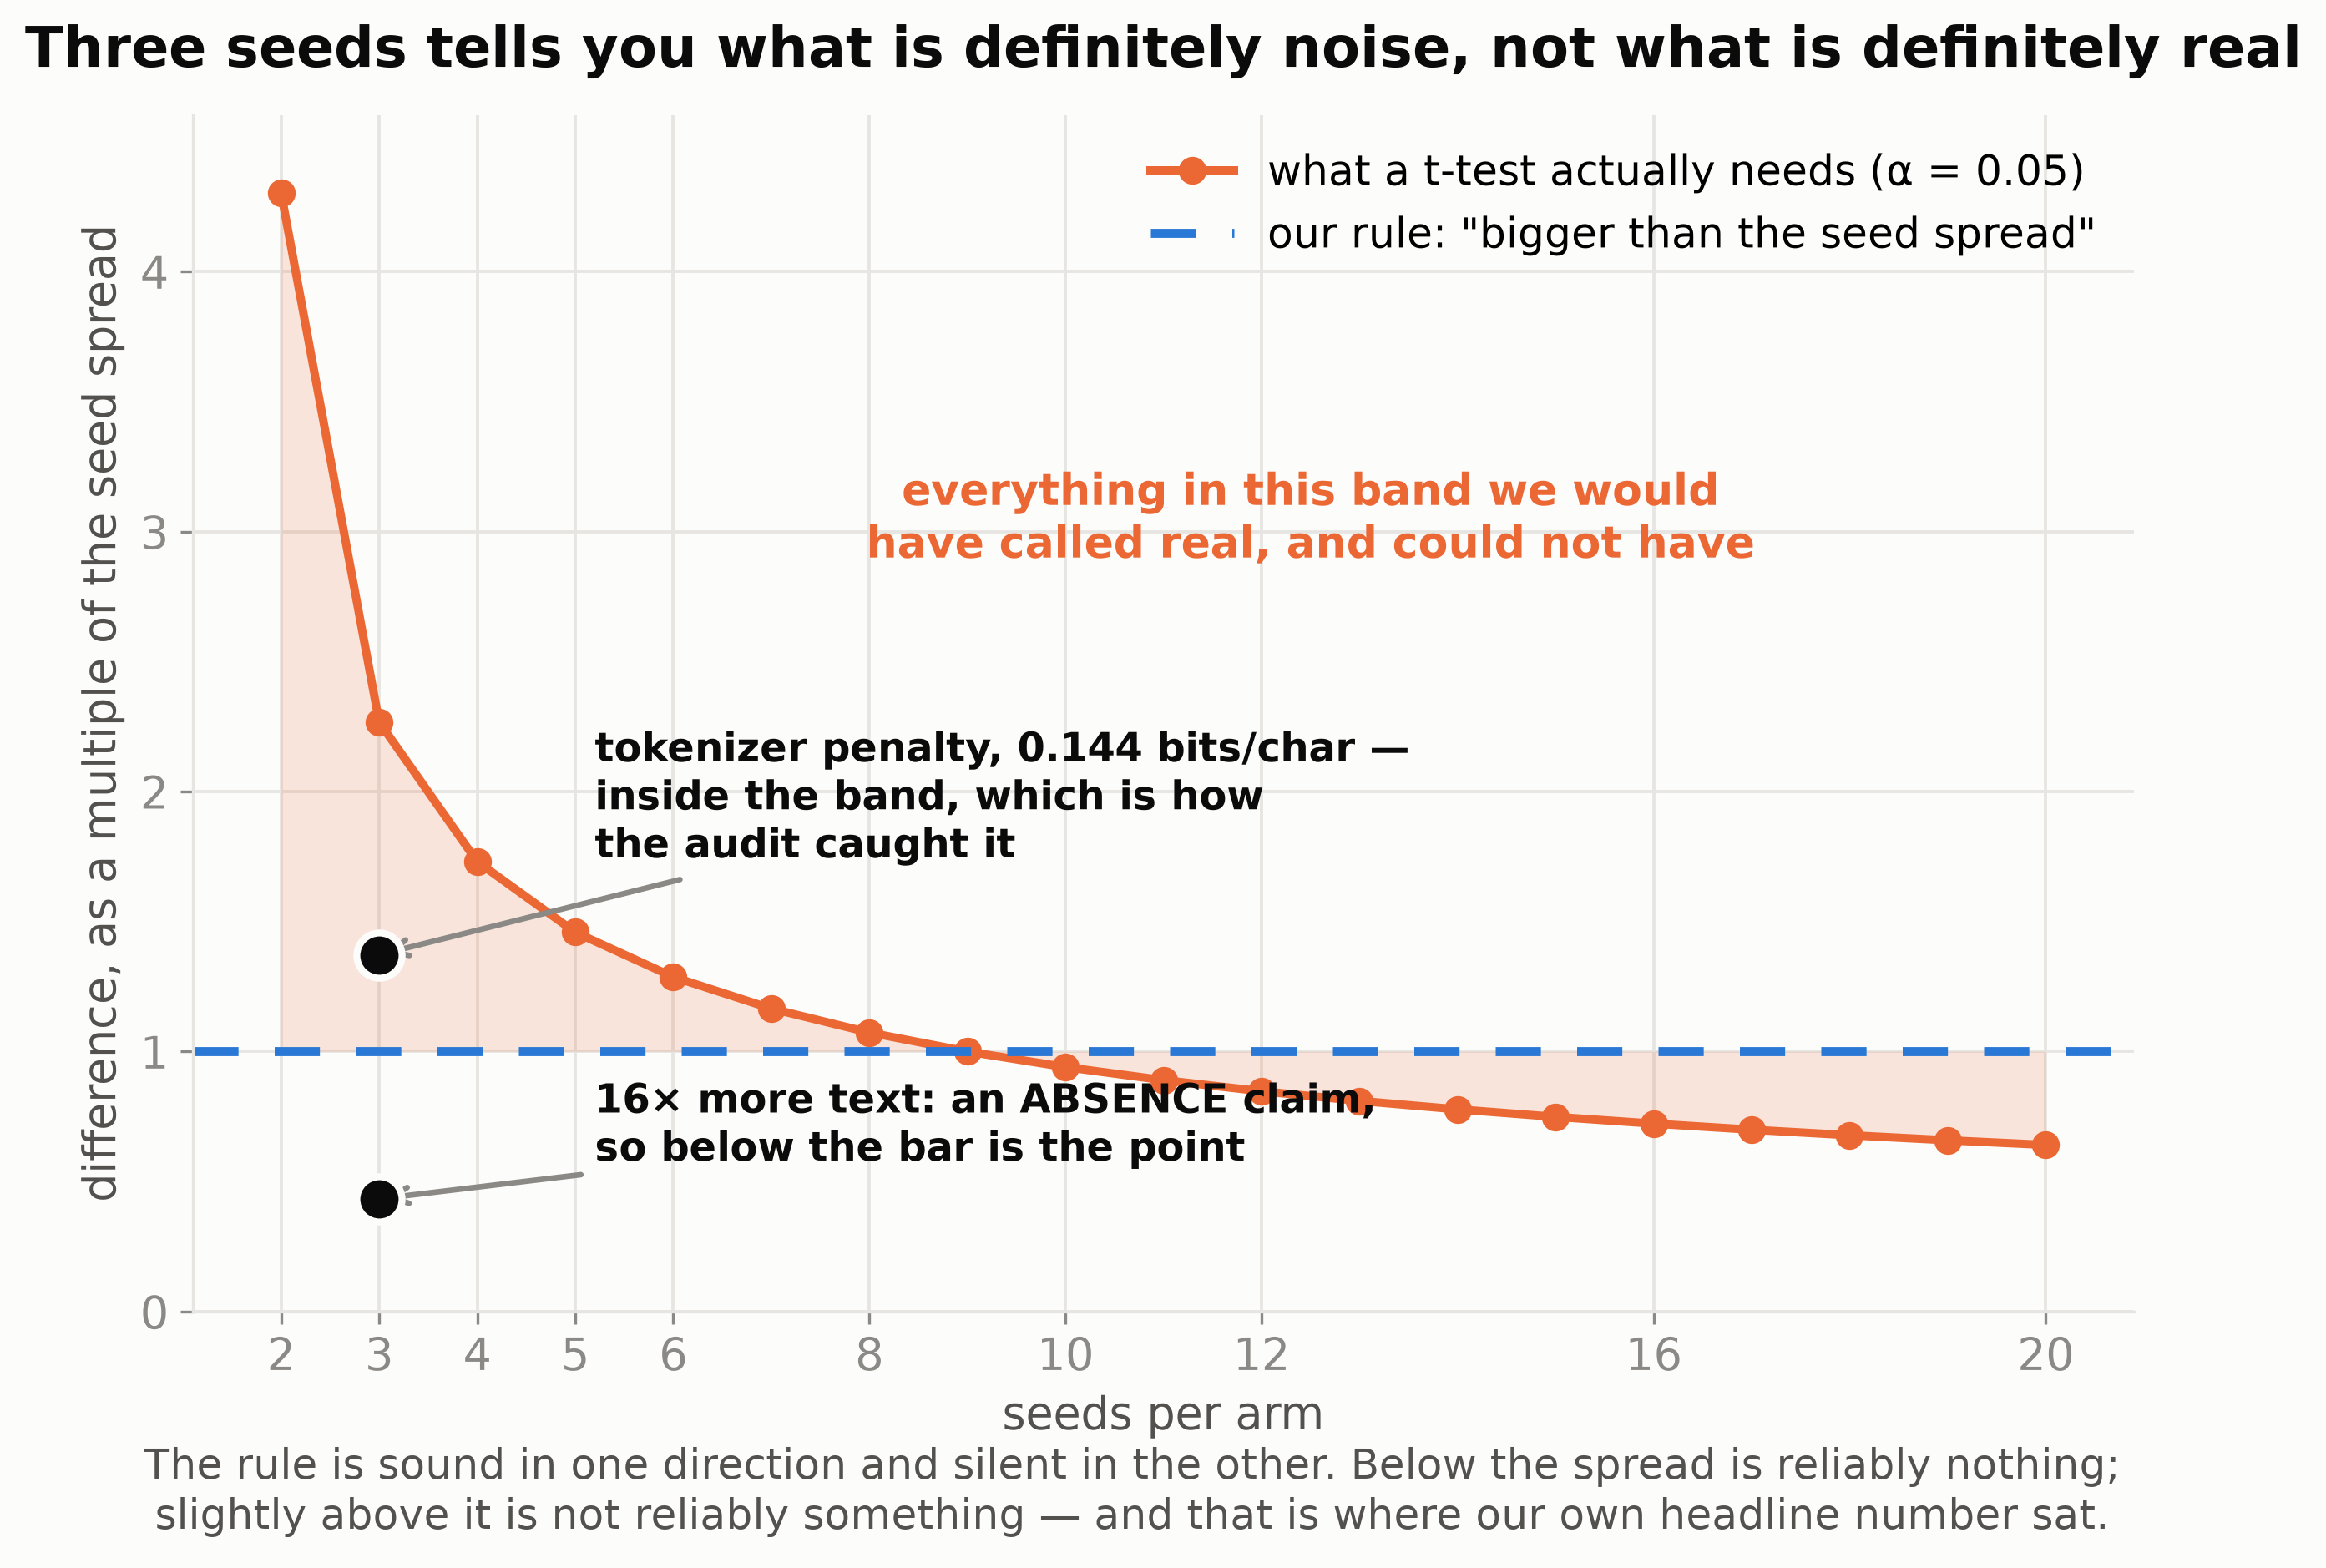

In [22]:
from scipy.stats import t as tdist

import claims_audit as ca
import study_tokenizer_seeds as tk

print(f"{'seeds/arm':>10}{'needed multiple of the spread':>32}{'exact-test floor':>20}")
for n in (2, 3, 4, 5, 6, 8, 10, 20):
    need = tdist.ppf(0.975, 2 * n - 2) * math.sqrt(2 / n)
    floor = 2.0 / math.comb(2 * n, n)
    flag = '   <- where we worked, against a threshold of 1.0' if n == 3 else ''
    print(f'{n:>10}{need:>32.2f}{floor:>20.4f}{flag}')

need3 = tdist.ppf(0.975, 4) * math.sqrt(2 / 3)
claim('required multiple at three seeds', need3, 'a difference must be **2.27×**')

# The second column is the sharper limit and the one nobody had noticed. At three a side an
# exact permutation test cannot return a p below 0.10 NO MATTER how far apart the arms land --
# there are only ten ways to split six numbers. So a three-seed experiment where every seed of
# one arm beats every seed of the other still reports p = 0.10, and a pre-registered n sets a
# floor on the p-value you are allowed to quote.
print()
print('Our own headline number against that bar, recomputed rather than quoted:')
BIG = next(x for x in tk.ARMS if x['corpus'] == 'yor_xlmr')
SMALL = next(x for x in tk.ARMS if x['corpus'] == 'yor')
big = sorted(tk.bpc(r, 'yor_xlmr') for r in tk.arm_records(BIG)[0].values())
small = sorted(tk.bpc(r, 'yor') for r in tk.arm_records(SMALL)[0].values())
gap = st.mean(big) - st.mean(small)
pooled = math.sqrt((st.stdev(big) ** 2 + st.stdev(small) ** 2) / 2)
pe, fl = ca.exact_p(big, small)
print(f'  tokenizer penalty  {gap:.3f} bits/char = {abs(gap)/pooled:.2f}x the pooled spread '
      f'at {len(big)} seeds a side')
print(f'  the bar at n={len(big)}       '
      f'{tdist.ppf(0.975, len(big)+len(small)-2)*math.sqrt(2/len(big)):.2f}x')
print(f'  exact permutation  p = {pe:.3f}   (floor {fl:.4f})')
print('  => at three seeds this read 0.144 and passed our rule at 1.4x. At six it is smaller,')
print('     not larger, and the arms interleave. The location claim is gone; the SPREAD is the')
print('     finding -- see the tokenizer cell above and figure 17.')

show('13-how-many-seeds')

### The gate that would have caught it

`claims_audit.py` states the null for every comparative claim on the board and computes the
statistic that would refute it. The staleness check above verifies that a *number* still matches
the records; this verifies that the *sentence wrapped around it* is supported. Every mistake this
project shipped lived in the gap between those two.


In [23]:
import subprocess, sys

# Run it as a subprocess rather than importing: it prints a report, and the report IS the output
# worth reading. Re-runs cheaply, touches no GPU.
out = subprocess.run([sys.executable, 'claims_audit.py'], capture_output=True, text=True)
print(out.stdout[-2600:] if out.stdout else out.stderr[-2000:])

ported seeds are the three the dev sweep used, so a residual selection channel remains.
   [tokenizer] seed 3 of yor_xlmr has 2 records -- swap_yor_xlmr_121.3M_12k_s3 (0.8379), swap_yor_xlmr_yor_xlmr_121.3M_12k_s3 (0.8538); took swap_yor_xlmr_yor_xlmr_121.3M_12k_s3

NOT SUPPORTED  the tokenizer penalty is real at matched compute
    the poster says : 0.059 bits per character
    the test        : Welch t = 0.97, p = 0.3738, n = 6 vs 6
                      exact permutation p = 0.335 (floor 0.0022 at 6v6)
                      the arms INTERLEAVE: 1 of 6 large-vocabulary runs land inside the small-vocabulary range
    note            : Six seeds a side, fixed in advance. The penalty did not grow into significance, it SHRANK --
                      0.144 bits/char at three seeds, 0.059 at six. There is no direction left to report.

SUPPORTED      the large vocabulary makes the RESULT less predictable
    the poster says : seed spread 0.145 against 0.037, 3.9x wider
    the test        

---
## The staleness check

Every number this notebook computed and marked with `claim()`, checked against what
`reports/09-the-bottom-report.md` actually says. **A `MISSING` row means the markdown has drifted from
the records** — go fix the prose, not this cell.

This is the same rule Patrick applied to run counts, pointed at the poster: generate the number
from the list rather than typing it beside it.

In [24]:
POSTER = 'reports/09-the-bottom-report.md'
raw = open(POSTER, encoding='utf-8').read()
# Collapse whitespace before searching. Markdown reflows every time a sentence is
# edited, so an anchor that spans a line break would report ANCHOR MOVED on a change
# that altered nothing -- a check that cries wolf gets switched off.
text = ' '.join(raw.split())

NUM = re.compile(r'-?\d[\d,]*\.?\d*')

checks = []
for c in CLAIMS:
    i = text.find(c['anchor'])
    if i < 0:
        status, quoted = 'ANCHOR MOVED', None
    else:
        # A window either side of the anchor, so the number may sit before or after the phrase.
        window = text[max(0, i - 220):i + 220]
        nums = [float(m.replace(',', '')) for m in NUM.findall(window) if m.strip('-,.')]
        want = abs(c['value'])
        near = [n for n in nums if abs(abs(n) - want) <= c['tol'] * max(1.0, want)]
        status = 'ok' if near else 'DRIFTED'
        quoted = near[0] if near else None
    checks.append({'claim': c['label'], 'computed': round(c['value'], 4),
                   'poster says': quoted, 'status': status})

df_check = pd.DataFrame(checks)
display(df_check)

bad = df_check[df_check['status'] != 'ok']
if len(bad):
    print(f'\n{len(bad)} of {len(df_check)} need attention:')
    print('  DRIFTED      the records moved and the prose did not -- update ' + POSTER)
    print('  ANCHOR MOVED the sentence was reworded -- update the anchor in the claim() call')
else:
    print(f'\nAll {len(df_check)} checked numbers still match the run records.')

# The counts Patrick asked us never to type on a wall.
print(f'\nas of now: {len(PRE)} pretraining runs, {len(DOWN)} downstream records, '
      f"{sum(len(r.get('scores') or []) for r in DOWN)} individual fine-tuning runs")

,claim,computed,poster says,status
0,"SIB-200, ours",0.6881,0.688,ok
1,"SIB-200, mmBERT",0.5822,0.582,ok
2,SIB-200 margin,0.1059,0.106,ok
3,corpora prepared,22.0000,22.000,ok
4,median seed spread,0.0710,0.071,ok
5,largest seed spread,2.1684,2.156,ok
6,tokenizer penalty at matched compute,0.0590,0.059,ok
7,passes over the corpus,14.8199,14.800,ok
8,"GPU-hours, total",143.2607,143.300,ok
9,own-vs-rent crossover,9333.3333,9300.000,ok



All 15 checked numbers still match the run records.

as of now: 197 pretraining runs, 161 downstream records, 541 individual fine-tuning runs


---
## What is not in here

Three panels of the bottom poster are argument rather than measurement, and there is nothing
honest for a notebook to compute about them. They live only in
[`reports/09-the-bottom-report.md`](reports/09-the-bottom-report.md):

- **Panel 11**, enabling the upstairs half — the test of that is the poster hanging above this
  one, not a number.
- **Panel 12**, how we used AI honestly — including the thing nobody predicted, that AI-drafted
  coordination email is what let three people who never met in person hand work off in hours.
- **Panel 13**, conclusions.

And the five-constants table — the one finding I would put at the center of the board — is a
table of judgments, not of measurements. It belongs in the prose.